# Analisis Status Gizi Anak Balita Periode 2021–2024

## 1.1 Pertanyaan Analisis

1. Bagaimana distribusi status gizi balita berdasarkan indikator BB/U pada periode tahun 2021–2024?
2. Apakah terdapat perbedaan status gizi (BB/U, TB/U, dan BB/TB) yang signifikan antara balita laki-laki dan perempuan berdasarkan data gabungan tahun 2021–2024?
3. Pada kelompok usia berapa kondisi TB/U balita mencapai nilai rata-rata Z-Score terendah sepanjang periode tahun 2021–2024?
4. Bagaimana tren pertumbuhan rata-rata berat badan dan tinggi badan balita berdasarkan usia bulan selama tahun 2021–2024?
5. Berapa prevalensi wasting berdasarkan BB/TB pada balita selama tahun 2021–2024, serta kelompok usia dan gender mana yang memiliki prevalensi tertinggi?

Notebook ini menggunakan data gabungan balita tahun 2021, 2022, 2023, dan 2024. Kolom `Tahun` digunakan untuk menandai asal tahun data agar analisis periode tetap konsisten.

## 1. Setup Library


In [1]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
os.makedirs("visualisasi_output", exist_ok=True)
os.makedirs("data_output", exist_ok=True)

sns.set_theme(style="white", context="talk")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

COLOR_GREEN = "#2fc75a"
COLOR_ORANGE = "#f28e00"
COLOR_RED = "#cf3a1d"
COLOR_PURPLE = "#9b59b6"
COLOR_BLUE = "#4C91D9"
COLOR_PINK = "#D9368B"
COLOR_TEAL = "#2A9D8F"
COLOR_NAVY = "#264653"
COLOR_GRAY = "#6c757d"

WFA_LABEL_MAP = {
    "Normal": "Normal",
    "Underfed": "Kurang Gizi",
    "Malnutrition": "Malnutrisi",
    "Overnutrition": "Gizi Lebih"
}

HFA_LABEL_MAP = {
    "Not Stunted": "Tidak Stunted",
    "Stunted": "Stunted"
}

WFH_LABEL_MAP = {
    "Normal": "Normal",
    "Thin": "Kurus",
    "Very Thin": "Sangat Kurus",
    "Obese": "Obesitas"
}

WFA_ORDER = ["Malnutrition", "Underfed", "Normal", "Overnutrition"]
WFH_ORDER = ["Very Thin", "Thin", "Normal", "Obese"]

WFA_COLORS = {
    "Malnutrition": COLOR_RED,
    "Underfed": COLOR_ORANGE,
    "Normal": COLOR_GREEN,
    "Overnutrition": COLOR_PURPLE
}

WFH_COLORS = {
    "Very Thin": COLOR_RED,
    "Thin": COLOR_ORANGE,
    "Normal": COLOR_GREEN,
    "Obese": COLOR_PURPLE
}


def add_bar_labels(ax, fmt="{:,.0f}", padding=3, fontsize=10):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=fontsize, fontweight="bold")


def save_fig(filename):
    path = f"visualisasi_output/{filename}"
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Gambar berhasil disimpan: {path}")


def format_percent(value, digits=2):
    return f"{value:.{digits}f}%"

## 2. Data Wrangling

Data wrangling terdiri dari proses memuat data, memeriksa kualitas data, membersihkan data, memperbaiki format variabel, dan menyiapkan dataset final untuk analisis.

### 2.1 Gathering Data

Dataset dimuat dari file Excel `overlldata.xlsx`. Pastikan file berada pada folder yang sama dengan notebook ini.

In [3]:
def baca_dataset(nama_file, tahun):
    df = pd.read_excel(nama_file)
    
    # Tambahkan kolom Tahun
    df["Tahun"] = tahun
    
    print(f"Berhasil membaca file: {nama_file}")
    print(f"Tahun data: {tahun}")
    print(f"Ukuran data: {df.shape[0]} baris, {df.shape[1]} kolom")
    
    return df

In [4]:
def tampilkan_kolom(df, nama_file):
    print(f"\nKolom pada file {nama_file}:")
    for kolom in df.columns:
        print(f"- {kolom}")



In [5]:
def cek_kolom_sama(dataframes):
    kolom_acuan = list(dataframes[0].columns)
    semua_sama = True

    for i, df in enumerate(dataframes):
        kolom_sekarang = list(df.columns)

        if kolom_sekarang != kolom_acuan:
            print(f"\nDataset ke-{i+1} memiliki kolom yang berbeda.")
            semua_sama = False

            kolom_hilang = set(kolom_acuan) - set(kolom_sekarang)
            kolom_tambahan = set(kolom_sekarang) - set(kolom_acuan)

            if kolom_hilang:
                print("Kolom yang hilang:", kolom_hilang)

            if kolom_tambahan:
                print("Kolom tambahan:", kolom_tambahan)

    if semua_sama:
        print("\nSemua dataset memiliki kolom yang sama.")
    else:
        print("\nTerdapat dataset yang memiliki kolom berbeda.")

    return semua_sama

In [6]:
def gabungkan_dataset(dataframes):
    data_gabungan = pd.concat(dataframes, ignore_index=True)
    print("Dataset berhasil digabungkan.")
    print("Ukuran data gabungan:", data_gabungan.shape)
    return data_gabungan

In [7]:
files = [
    "2021.xlsx",
    "2022.xlsx",
    "2023.xlsx",
    "2024.xlsx"
]

dataframes = []

for file in files:
    # Ambil tahun dari nama file (mis. '2021.xlsx' -> 2021)
    tahun = int(str(file).split('.')[0])
    df = baca_dataset(file, tahun)
    tampilkan_kolom(df, file)
    dataframes.append(df)

hasil_cek = cek_kolom_sama(dataframes)

if hasil_cek:
    data_gabungan = gabungkan_dataset(dataframes)
else:
    print("Dataset tidak digabungkan karena terdapat perbedaan kolom.")

Berhasil membaca file: 2021.xlsx
Tahun data: 2021
Ukuran data: 3412 baris, 12 kolom

Kolom pada file 2021.xlsx:
- No.
- Gender
- Age (Month)
- Weight
- Height
- Weight for Age
- Z-Score  W/A
- Height for Age
- Z-Score H/A
- Weight for Height
- Z-Score W/H
- Tahun
Berhasil membaca file: 2022.xlsx
Tahun data: 2022
Ukuran data: 1111 baris, 12 kolom

Kolom pada file 2022.xlsx:
- No.
- Gender
- Age (Month)
- Weight
- Height
- Weight for Age
- Z-Score  W/A
- Height for Age
- Z-Score H/A
- Weight for Height
- Z-Score W/H
- Tahun
Berhasil membaca file: 2023.xlsx
Tahun data: 2023
Ukuran data: 3808 baris, 12 kolom

Kolom pada file 2023.xlsx:
- No.
- Gender
- Age (Month)
- Weight
- Height
- Weight for Age
- Z-Score  W/A
- Height for Age
- Z-Score H/A
- Weight for Height
- Z-Score W/H
- Tahun
Berhasil membaca file: 2024.xlsx
Tahun data: 2024
Ukuran data: 31740 baris, 12 kolom

Kolom pada file 2024.xlsx:
- No.
- Gender
- Age (Month)
- Weight
- Height
- Weight for Age
- Z-Score  W/A
- Height for Age

In [8]:
# Simpan file hanya jika data_gabungan tersedia
if 'data_gabungan' in globals():
    data_gabungan.to_excel("overlldata.xlsx", index=False)
    print("File tersimpan: overlldata.xlsx")
else:
    print("Tidak ada data_gabungan untuk disimpan.")

File tersimpan: overlldata.xlsx


In [9]:
# Membaca dataset
file_path = "overlldata.xlsx"
df_raw = pd.read_excel(file_path)

# Menampilkan lima data pertama
df_raw.head()

,No.,Gender,Age (Month),Weight,Height,Weight for Age,Z-Score W/A,Height for Age,Z-Score H/A,Weight for Height,Z-Score W/H,Tahun
0,1,F,54.0,13.2,97.5,Normal,-1.94,Stunted,-2.11,Normal,-0.95,2021
1,2,M,44.0,12,92.0,Normal,-1.92,Stunted,-2.22,Normal,-0.88,2021
2,3,M,57.0,14,97.0,Normal,-1.9,Stunted,-2.58,Normal,-0.48,2021
3,4,M,26.0,11,79.0,Normal,-1.15,Stunted,-3.11,Normal,0.68,2021
4,5,F,59.0,14.6,98.0,Normal,-1.66,Stunted,-2.49,Normal,-0.18,2021


In [10]:
print("Jumlah baris:", df_raw.shape[0])
print("Jumlah kolom:", df_raw.shape[1])

Jumlah baris: 40071
Jumlah kolom: 12


Output ini menunjukkan ukuran awal dataset sebelum proses pembersihan. Pada dataset terbaru, jumlah data jauh lebih besar dibanding dataset sebelumnya, sehingga analisis tidak lagi hanya terbatas pada sebagian kecil balita. Ukuran dataset awal menjadi dasar untuk membandingkan berapa banyak data yang terhapus setelah cleaning.

### 2.2 Assessing Data

Tahap assessing dilakukan untuk memeriksa struktur data, tipe data, missing value, duplikasi, dan konsistensi kategori.

In [11]:
# Informasi struktur data
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 40071 entries, 0 to 40070
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                40071 non-null  int64  
 1   Gender             40071 non-null  str    
 2   Age (Month)        40069 non-null  float64
 3   Weight             40071 non-null  object 
 4   Height             40071 non-null  float64
 5   Weight for Age     40071 non-null  str    
 6   Z-Score  W/A       40071 non-null  object 
 7   Height for Age     40071 non-null  str    
 8   Z-Score H/A        40071 non-null  object 
 9   Weight for Height  40066 non-null  str    
 10  Z-Score W/H        40071 non-null  object 
 11  Tahun              40071 non-null  int64  
dtypes: float64(2), int64(2), object(4), str(4)
memory usage: 4.6+ MB


In [12]:
# Missing value sebelum cleaning
missing_before = pd.DataFrame({
    "Jumlah": df_raw.isna().sum(),
    "Persen (%)": (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})

missing_before

,Jumlah,Persen (%)
No.,0,0.00
Gender,0,0.00
Age (Month),2,0.00
Weight,0,0.00
Height,0,0.00
Weight for Age,0,0.00
Z-Score W/A,0,0.00
Height for Age,0,0.00
Z-Score H/A,0,0.00
Weight for Height,5,0.01


Pengecekan missing value digunakan untuk melihat kolom mana yang belum lengkap. Pada dataset ini, missing value utama ditemukan pada `Age (Month)` dan `Weight for Height`, sedangkan kolom lain relatif lengkap. Karena jumlah missing value kecil, penanganannya dapat dilakukan dengan menghapus baris yang tidak lengkap pada kolom penting setelah proses konversi tipe data selesai.

In [13]:
# Cek data duplikat
print("Jumlah data duplikat:", df_raw.duplicated().sum())

Jumlah data duplikat: 0


In [14]:
# Cek kolom numerik yang masih terbaca object
numeric_candidate_cols = [
    "No.",
    "Age (Month)",
    "Weight",
    "Height",
    "Z-Score  W/A",
    "Z-Score H/A",
    "Z-Score W/H"
]

df_raw[numeric_candidate_cols].dtypes

No.               int64
Age (Month)     float64
Weight           object
Height          float64
Z-Score  W/A     object
Z-Score H/A      object
Z-Score W/H      object
dtype: object

Kolom `No.`, `Age (Month)`, dan `Height` sudah terbaca sebagai numerik. Namun, `Weight`, `Z-Score W/A`, `Z-Score H/A`, dan `Z-Score W/H` masih terbaca sebagai `object`, padahal kolom tersebut harus digunakan untuk perhitungan statistik. Oleh karena itu, kolom-kolom ini perlu dikonversi menjadi numerik pada tahap cleaning.

In [15]:
# Cek contoh isi kolom numerik yang bermasalah
df_raw[["Weight", "Z-Score  W/A", "Z-Score H/A", "Z-Score W/H"]].head(20)

,Weight,Z-Score W/A,Z-Score H/A,Z-Score W/H
0,13.2,-1.94,-2.11,-0.95
1,12,-1.92,-2.22,-0.88
2,14,-1.9,-2.58,-0.48
3,11,-1.15,-3.11,0.68
4,14.6,-1.66,-2.49,-0.18
5,11,-2.74,-2.87,-1.44
6,14,-1.75,-2.49,-0.28
7,14,-1.4,-2.53,0.2
8,14.2,-1.86,-3.04,0.04
9,10,-4.12,-5.82,-0.5


In [ ]:
                                                                                                                                ``````````````````````````# Cek nilai unik pada kolom kategorikal
categorical_cols = ["Gender", "Weight for Age", "Height for Age", "Weight for Height"]

for col in categorical_cols:
    print(f"\nKolom: {col}")
    print(df_raw[col].value_counts(dropna=False))


Kolom: Gender
Gender
M    21987
F    18084
Name: count, dtype: int64

Kolom: Weight for Age
Weight for Age
Normal           30932
Underfed          7060
Malnutrition      1803
Overnutrition      276
Name: count, dtype: int64

Kolom: Height for Age
Height for Age
Not Stunted    23867
Stunted        16204
Name: count, dtype: int64

Kolom: Weight for Height
Weight for Height
Normal       37006
Thin          2124
Obese          569
Very Thin      367
NaN              5
Name: count, dtype: int64


**Interpretasi kategori:**  
Kolom kategorikal sudah cukup konsisten. `Gender` hanya berisi `M` dan `F`; `Weight for Age` terdiri dari `Normal`, `Underfed`, `Malnutrition`, dan `Overnutrition`; `Height for Age` terdiri dari `Stunted` dan `Not Stunted`; sedangkan `Weight for Height` terdiri dari `Normal`, `Thin`, `Very Thin`, dan `Obese`. Temuan pentingnya adalah dataset terbaru tidak hanya berisi balita stunted, tetapi juga balita not stunted.


**assessing data:**

- Kolom `Weight`, `Z-Score W/A`, `Z-Score H/A`, dan `Z-Score W/H` perlu dikonversi menjadi numerik.
- Sebagian nilai pada kolom `Weight` terbaca sebagai format tanggal dari Excel sehingga perlu diperbaiki.
- Kolom `No.` hanya berfungsi sebagai nomor urut sehingga tidak digunakan dalam analisis.
- Dataset terbaru memuat status `Stunted` dan `Not Stunted`, sehingga analisis dilakukan pada seluruh balita, bukan hanya balita stunted.

### 2.3 Cleaning Data

Tahap cleaning dilakukan dengan menghapus kolom yang tidak diperlukan, memperbaiki kolom `Weight`, mengonversi Z-Score menjadi numerik, menangani missing value, dan menghapus nilai ekstrem yang tidak wajar.

In [17]:
# Membuat salinan data agar data mentah tetap aman
df_clean = df_raw.copy()

In [18]:
# Hapus kolom No
if "No." in df_clean.columns:
    df_clean = df_clean.drop(columns=["No."])

In [19]:
def fix_weight_robust(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return value

    if isinstance(value, (pd.Timestamp, datetime)):
        return value.day + (value.month / 10)

    value_str = str(value).strip()

    # Coba deteksi teks tanggal akibat salah format Excel
    parsed_date = pd.to_datetime(value_str, errors="coerce")
    if pd.notna(parsed_date) and "2025-" in value_str:
        return parsed_date.day + (parsed_date.month / 10)

    # Jika teks angka biasa
    value_str = value_str.replace(",", ".")
    return pd.to_numeric(value_str, errors="coerce")


df_clean["Weight"] = df_raw["Weight"].apply(fix_weight_robust)

**Interpretasi cleaning Weight:**  
Kolom `Weight` diperbaiki karena sebagian nilai berat badan terbaca sebagai tanggal akibat format Excel. Contohnya, nilai seperti `2025-02-08` diasumsikan sebagai 8,2 kg, yaitu hari sebagai angka utama dan bulan sebagai desimal. Perbaikan ini penting agar data berat badan tidak berubah menjadi missing atau nilai tidak valid saat dikonversi menjadi numerik.

In [20]:
# Konversi kolom Z-Score menjadi numerik
zscore_cols = ["Z-Score  W/A", "Z-Score H/A", "Z-Score W/H"]

for col in zscore_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Pastikan Weight numerik
df_clean["Weight"] = pd.to_numeric(df_clean["Weight"], errors="coerce")

In [21]:
# Missing value setelah konversi tipe data
missing_after_conversion = pd.DataFrame({
    "Jumlah": df_clean.isna().sum(),
    "Persen (%)": (df_clean.isna().sum() / len(df_clean) * 100).round(2)
})

missing_after_conversion

,Jumlah,Persen (%)
Gender,0,0.00
Age (Month),2,0.00
Weight,0,0.00
Height,0,0.00
Weight for Age,0,0.00
Z-Score W/A,65,0.16
Height for Age,0,0.00
Z-Score H/A,216,0.54
Weight for Height,5,0.01
Z-Score W/H,270,0.67


**Interpretasi setelah konversi:**  
Setelah proses konversi, kolom `Weight` dan Z-Score dapat dihitung sebagai data numerik. Jika masih terdapat missing value setelah konversi, berarti terdapat nilai yang memang tidak dapat dibaca sebagai angka atau kategori yang tidak lengkap. Missing value ini kemudian ditangani pada tahap berikutnya.

In [22]:
# Hapus baris yang memiliki missing value pada kolom penting
df_clean = df_clean.dropna(subset=[
    "Age (Month)",
    "Weight",
    "Height",
    "Z-Score  W/A",
    "Z-Score H/A",
    "Weight for Height",
    "Z-Score W/H"
]).copy()

print("Jumlah data awal:", df_raw.shape[0])
print("Jumlah data setelah drop missing:", df_clean.shape[0])
print("Jumlah data yang dihapus:", df_raw.shape[0] - df_clean.shape[0])

Jumlah data awal: 40071
Jumlah data setelah drop missing: 39529
Jumlah data yang dihapus: 542


**Interpretasi penghapusan missing value:**  
Baris dengan missing value pada kolom penting dihapus agar analisis statistik tidak bias oleh data kosong. Karena jumlah data yang dihapus relatif kecil dibanding total dataset, proses ini masih aman dan tidak mengurangi representasi data secara besar.

In [23]:
# Rename kolom agar lebih mudah dipakai
df_clean = df_clean.rename(columns={
    "Age (Month)": "Age_Month",
    "Weight for Age": "WFA_Status",
    "Z-Score  W/A": "ZScore_WA",
    "Height for Age": "HFA_Status",
    "Z-Score H/A": "ZScore_HA",
    "Weight for Height": "WFH_Status",
    "Z-Score W/H": "ZScore_WH"
})

# Reset index
df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,Gender,Age_Month,Weight,Height,WFA_Status,ZScore_WA,HFA_Status,ZScore_HA,WFH_Status,ZScore_WH,Tahun
0,F,54.0,13.2,97.5,Normal,-1.94,Stunted,-2.11,Normal,-0.95,2021
1,M,44.0,12.0,92.0,Normal,-1.92,Stunted,-2.22,Normal,-0.88,2021
2,M,57.0,14.0,97.0,Normal,-1.90,Stunted,-2.58,Normal,-0.48,2021
3,M,26.0,11.0,79.0,Normal,-1.15,Stunted,-3.11,Normal,0.68,2021
4,F,59.0,14.6,98.0,Normal,-1.66,Stunted,-2.49,Normal,-0.18,2021


In [24]:
# Cek statistik deskriptif awal setelah cleaning missing
df_clean[["Age_Month", "Weight", "Height", "ZScore_WA", "ZScore_HA", "ZScore_WH"]].describe()

,Age_Month,Weight,Height,ZScore_WA,ZScore_HA,ZScore_WH
count,39529.000000,39529.000000,39529.000000,39529.000000,39529.000000,39529.000000
mean,33.132106,11.660438,86.071107,-1.051972,-1.758021,-0.008502
std,15.796822,30.405812,11.775628,39.739879,1.155717,65.775366
min,0.000000,2.000000,44.000000,-5.800000,-7.270000,-5.890000
25%,20.000000,9.500000,78.000000,-1.930000,-2.460000,-1.200000
50%,34.000000,11.500000,87.300000,-1.350000,-1.810000,-0.620000
75%,47.000000,13.400000,95.200000,-0.820000,-1.050000,0.010000
max,60.000000,3100.000000,120.000000,4622.490000,5.930000,7657.390000


In [25]:
# Deteksi nilai ekstrem tidak wajar
invalid_condition = (
    (df_clean["Weight"] > 40) |
    (df_clean["ZScore_WA"] < -10) | (df_clean["ZScore_WA"] > 10) |
    (df_clean["ZScore_HA"] < -10) | (df_clean["ZScore_HA"] > 10) |
    (df_clean["ZScore_WH"] < -10) | (df_clean["ZScore_WH"] > 10)
)

print("Jumlah data tidak wajar:", invalid_condition.sum())
df_clean[invalid_condition].head(20)

Jumlah data tidak wajar: 4


,Gender,Age_Month,Weight,Height,WFA_Status,ZScore_WA,HFA_Status,ZScore_HA,WFH_Status,ZScore_WH,Tahun
38923,M,0.0,3085.0,49.0,Normal,-0.90,Not Stunted,-0.84,Normal,-0.65,2024
39449,F,0.0,3100.0,49.0,Overnutrition,4449.75,Not Stunted,-1.30,Normal,7469.59,2024
39471,M,0.0,2900.0,48.0,Overnutrition,4603.42,Not Stunted,-0.90,Normal,7657.39,2024
39486,M,0.0,3000.0,49.0,Overnutrition,4622.49,Not Stunted,-0.74,Normal,7518.63,2024


**Interpretasi validasi nilai ekstrem:**  
Nilai ekstrem tidak wajar dicek menggunakan batas logis antropometri. Berat badan balita di atas 40 kg atau Z-Score di luar rentang -10 sampai 10 dianggap tidak valid. Pada dataset ini ditemukan beberapa data ekstrem seperti berat badan ribuan kilogram dan Z-Score ribuan, sehingga data tersebut perlu dihapus karena kemungkinan berasal dari kesalahan format.

In [26]:
# Menghapus data dengan nilai antropometri tidak wajar
df_clean = df_clean[~invalid_condition].copy()
df_clean = df_clean.reset_index(drop=True)

print("Jumlah data final setelah cleaning:", df_clean.shape[0])

Jumlah data final setelah cleaning: 39525


In [27]:
# Cek struktur data final setelah cleaning
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 39525 entries, 0 to 39524
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      39525 non-null  str    
 1   Age_Month   39525 non-null  float64
 2   Weight      39525 non-null  float64
 3   Height      39525 non-null  float64
 4   WFA_Status  39525 non-null  str    
 5   ZScore_WA   39525 non-null  float64
 6   HFA_Status  39525 non-null  str    
 7   ZScore_HA   39525 non-null  float64
 8   WFH_Status  39525 non-null  str    
 9   ZScore_WH   39525 non-null  float64
 10  Tahun       39525 non-null  int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 4.2 MB


In [28]:
# Statistik deskriptif final setelah membersihkan nilai tidak wajar
df_clean[["Age_Month", "Weight", "Height", "ZScore_WA", "ZScore_HA", "ZScore_WH"]].describe()

,Age_Month,Weight,Height,ZScore_WA,ZScore_HA,ZScore_WH
count,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000
mean,33.135459,11.355862,86.074884,-1.398056,-1.758103,-0.581431
std,15.794104,2.683234,11.770236,0.903110,1.155745,1.010247
min,0.000000,2.000000,44.000000,-5.800000,-7.270000,-5.890000
25%,20.000000,9.500000,78.000000,-1.930000,-2.460000,-1.200000
50%,34.000000,11.500000,87.300000,-1.350000,-1.810000,-0.620000
75%,47.000000,13.400000,95.200000,-0.820000,-1.050000,0.010000
max,60.000000,26.600000,120.000000,3.690000,5.930000,5.970000


**Interpretasi statistik final:**  
Setelah data tidak wajar dihapus, statistik deskriptif menjadi lebih masuk akal. Berat badan maksimum turun ke rentang yang realistis untuk balita, dan nilai Z-Score tidak lagi berada pada angka ribuan. Dengan demikian, dataset final sudah layak digunakan untuk analisis EDA dan visualisasi.

### 2.4 Ringkasan Hasil Cleaning

Hasil cleaning menghasilkan dataset final yang sudah siap dianalisis. Kolom `Weight` berhasil diperbaiki dari format tanggal menjadi numerik. Kolom Z-Score telah dikonversi menjadi numerik. Baris dengan missing value pada kolom penting dihapus, dan data ekstrem tidak wajar juga dihapus agar tidak mengganggu analisis.

## 3. Data Understanding

Bagian ini menjelaskan gambaran umum dataset, data dictionary, dan struktur variabel yang digunakan dalam analisis.

### 3.1 Gambaran Umum Dataset

Dataset berisi data antropometri balita periode 2021–2024 dengan variabel usia, gender, berat badan, tinggi badan, status gizi berdasarkan BB/U, TB/U, BB/TB, serta nilai Z-Score. Setelah cleaning, dataset siap digunakan untuk analisis deskriptif, eksploratif, dan uji statistik.

### 3.2 Data Dictionary

| Kolom | Tipe Data | Deskripsi | Contoh Nilai |
|---|---|---|---|
| Gender | Kategorikal | Jenis kelamin balita | M, F |
| Age_Month | Numerik | Usia balita dalam bulan | 24 |
| Weight | Numerik | Berat badan balita dalam kilogram | 10.5 |
| Height | Numerik | Tinggi badan balita dalam sentimeter | 82.0 |
| WFA_Status | Kategorikal | Status gizi berdasarkan berat badan menurut umur atau BB/U | Normal, Underfed, Malnutrition, Overnutrition |
| ZScore_WA | Numerik | Nilai Z-Score berat badan menurut umur | -2.35 |
| HFA_Status | Kategorikal | Status gizi berdasarkan tinggi badan menurut umur atau TB/U | Stunted, Not Stunted |
| ZScore_HA | Numerik | Nilai Z-Score tinggi badan menurut umur | -2.80 |
| WFH_Status | Kategorikal | Status gizi berdasarkan berat badan menurut tinggi badan atau BB/TB | Normal, Thin, Very Thin, Obese |
| ZScore_WH | Numerik | Nilai Z-Score berat badan menurut tinggi badan | -1.20 |

### 3.3 Struktur Variabel

Variabel dalam dataset dapat dikelompokkan menjadi:

- **Variabel identitas dasar:** `Gender`, `Age_Month`
- **Variabel antropometri:** `Weight`, `Height`
- **Variabel status gizi:** `WFA_Status`, `HFA_Status`, `WFH_Status`
- **Variabel Z-Score:** `ZScore_WA`, `ZScore_HA`, `ZScore_WH`

## 4. Feature Engineering

Feature engineering dilakukan sebelum EDA lanjutan karena beberapa visualisasi dan insight membutuhkan kolom tambahan seperti kelompok usia, label gender, indikator stunting, indikator wasting, double burden, dan gizi kritis.

In [29]:
# Kelompok usia
bins = [0, 12, 24, 36, 48, 60]
labels = ["0-12 bulan", "13-24 bulan", "25-36 bulan", "37-48 bulan", "49-60 bulan"]
short_labels = ["0-12 bln", "13-24 bln", "25-36 bln", "37-48 bln", "49-60 bln"]

df_clean["Age_Group"] = pd.cut(
    df_clean["Age_Month"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_clean["Age_Group_Short"] = df_clean["Age_Group"].cat.rename_categories(short_labels)

# Label gender
df_clean["Gender_Label"] = df_clean["Gender"].map({
    "M": "Laki-laki",
    "F": "Perempuan"
})

# Label status dalam Bahasa Indonesia agar tabel dan grafik lebih mudah dibaca
df_clean["Status_BBU_Label"] = df_clean["WFA_Status"].map(WFA_LABEL_MAP)
df_clean["Status_TBU_Label"] = df_clean["HFA_Status"].map(HFA_LABEL_MAP)
df_clean["Status_BBTB_Label"] = df_clean["WFH_Status"].map(WFH_LABEL_MAP)

# Indikator status gizi
df_clean["Is_Stunted"] = df_clean["HFA_Status"] == "Stunted"
df_clean["Is_Wasting"] = df_clean["WFH_Status"].isin(["Thin", "Very Thin"])
df_clean["Is_Severe_Stunted"] = df_clean["ZScore_HA"] < -3

# Insight gabungan
df_clean["Double_Burden"] = df_clean["Is_Stunted"] & df_clean["Is_Wasting"]
df_clean["Gizi_Kritis"] = (df_clean["WFA_Status"] == "Malnutrition") & (df_clean["HFA_Status"] == "Stunted")

# Fitur tambahan untuk korelasi
df_clean["BMI"] = df_clean["Weight"] / ((df_clean["Height"] / 100) ** 2)
df_clean["Total_ZScore"] = df_clean["ZScore_WA"] + df_clean["ZScore_HA"] + df_clean["ZScore_WH"]

# Validasi rentang tahun data
print("Rentang tahun pada data:", sorted(df_clean["Tahun"].dropna().unique()))
print("Jumlah data per tahun:")
display(df_clean["Tahun"].value_counts().sort_index().rename_axis("Tahun").reset_index(name="Jumlah"))

df_clean[["Tahun", "Gender", "Gender_Label", "Age_Month", "Age_Group", "WFA_Status", "HFA_Status", "WFH_Status", "Is_Wasting"]].head()

Rentang tahun pada data: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Jumlah data per tahun:


,Tahun,Jumlah
0,2021,3410
1,2022,1111
2,2023,3807
3,2024,31197


,Tahun,Gender,Gender_Label,Age_Month,Age_Group,WFA_Status,HFA_Status,WFH_Status,Is_Wasting
0,2021,F,Perempuan,54.0,49-60 bulan,Normal,Stunted,Normal,False
1,2021,M,Laki-laki,44.0,37-48 bulan,Normal,Stunted,Normal,False
2,2021,M,Laki-laki,57.0,49-60 bulan,Normal,Stunted,Normal,False
3,2021,M,Laki-laki,26.0,25-36 bulan,Normal,Stunted,Normal,False
4,2021,F,Perempuan,59.0,49-60 bulan,Normal,Stunted,Normal,False


**Interpretasi feature engineering:**  
Kolom baru dibuat untuk mempermudah analisis. `Age_Group` digunakan untuk melihat pola berdasarkan kelompok usia, `Gender_Label` membuat label gender lebih mudah dibaca, `Is_Stunted` dan `Is_Wasting` membantu menghitung prevalensi, sedangkan `Double_Burden` dan `Gizi_Kritis` digunakan untuk mengidentifikasi kelompok balita dengan risiko gizi lebih serius.

## 5. Exploratory Data Analysis (EDA)

EDA digunakan untuk memahami distribusi data, pola Z-Score, tren antropometri, korelasi variabel, serta insight gabungan dari beberapa indikator gizi.

### 5.1 Statistik Deskriptif

In [30]:
# Statistik deskriptif kolom numerik
df_clean[["Age_Month", "Weight", "Height", "ZScore_WA", "ZScore_HA", "ZScore_WH", "BMI", "Total_ZScore"]].describe()

,Age_Month,Weight,Height,ZScore_WA,ZScore_HA,ZScore_WH,BMI,Total_ZScore
count,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000,39525.000000
mean,33.135459,11.355862,86.074884,-1.398056,-1.758103,-0.581431,15.216985,-3.737590
std,15.794104,2.683234,11.770236,0.903110,1.155745,1.010247,1.490022,2.340565
min,0.000000,2.000000,44.000000,-5.800000,-7.270000,-5.890000,9.053871,-15.370000
25%,20.000000,9.500000,78.000000,-1.930000,-2.460000,-1.200000,14.225298,-5.110000
50%,34.000000,11.500000,87.300000,-1.350000,-1.810000,-0.620000,15.030639,-3.630000
75%,47.000000,13.400000,95.200000,-0.820000,-1.050000,0.010000,16.017190,-2.240000
max,60.000000,26.600000,120.000000,3.690000,5.930000,5.970000,26.944444,8.940000


Berdasarkan statistik deskriptif, data bersih berjumlah 39.525 balita dan sudah tidak memiliki missing value pada variabel utama.

Usia balita berada pada rentang 0–60 bulan dengan rata-rata 33,14 bulan. Berat badan rata-rata 11,36 kg, tinggi badan rata-rata 86,07 cm, dan BMI rata-rata 15,22, sehingga data antropometri sudah terlihat wajar setelah cleaning.

Rata-rata semua Z-score bernilai negatif, yaitu ZScore_WA = -1,398, ZScore_HA = -1,758, dan ZScore_WH = -0,581. Artinya, kondisi gizi balita dalam data ini cenderung berada di bawah standar median rujukan. Nilai terendah terdapat pada ZScore_HA, sehingga masalah TB/U atau stunting menjadi indikator yang paling menonjol.

Namun, masih ada nilai Z-score yang cukup ekstrem, terutama ZScore_HA minimum -7,27 dan maksimum 5,93, sehingga perlu dicek lagi apakah masih ingin dipertahankan atau difilter lebih lanjut.

### 5.2 Distribusi Data

In [31]:
# Distribusi gender
gender_df = pd.DataFrame({
    "Jumlah": df_clean["Gender_Label"].value_counts(),
    "Persen (%)": (df_clean["Gender_Label"].value_counts(normalize=True) * 100).round(2)
})

gender_df

,Jumlah,Persen (%)
Gender_Label,,
Laki-laki,21720,54.95
Perempuan,17805,45.05


Distribusi gender pada data bersih menunjukkan bahwa balita laki-laki berjumlah 21.720 orang (54,95%), sedangkan balita perempuan berjumlah 17.805 orang (45,05%).

Artinya, data sedikit lebih banyak didominasi oleh balita laki-laki. Namun, selisihnya tidak terlalu besar, sehingga distribusi gender masih tergolong cukup seimbang untuk analisis perbandingan status gizi antara laki-laki dan perempuan.

In [32]:
# Distribusi kelompok usia
age_group_df = pd.DataFrame({
    "Jumlah": df_clean["Age_Group"].value_counts().sort_index(),
    "Persen (%)": (df_clean["Age_Group"].value_counts(normalize=True).sort_index() * 100).round(2)
})

age_group_df

,Jumlah,Persen (%)
Age_Group,,
0-12 bulan,4808,12.16
13-24 bulan,8073,20.43
25-36 bulan,8958,22.66
37-48 bulan,9162,23.18
49-60 bulan,8524,21.57


Kelompok usia paling sedikit adalah 0–12 bulan, yaitu 4.808 balita (12,16%). Sementara itu, kelompok usia 13–60 bulan memiliki proporsi yang relatif seimbang, berkisar antara 20,43% sampai 23,18%.

In [33]:
# Distribusi status BB/U periode 2021–2024
wfa_count = df_clean["WFA_Status"].value_counts().reindex(WFA_ORDER).fillna(0).astype(int)
wfa_df = (
    pd.DataFrame({
        "Status BB/U": [WFA_LABEL_MAP.get(i, i) for i in wfa_count.index],
        "Jumlah": wfa_count.values,
        "Persentase (%)": (wfa_count.values / wfa_count.sum() * 100).round(2)
    })
)

wfa_df

,Status BB/U,Jumlah,Persentase (%)
0,Malnutrisi,1800,4.55
1,Kurang Gizi,7054,17.85
2,Normal,30509,77.19
3,Gizi Lebih,162,0.41


**Interpretasi status BB/U:**  
Status BB/U digunakan untuk melihat berat badan balita menurut umur. Mayoritas balita berada pada kategori normal, tetapi kategori `Underfed` dan `Malnutrition` tetap perlu diperhatikan karena menunjukkan masalah gizi kurang. Kategori `Overnutrition` menunjukkan adanya sebagian kecil balita dengan gizi lebih.

In [34]:
# Distribusi status TB/U periode 2021–2024
hfa_count = df_clean["HFA_Status"].value_counts()
hfa_df = (
    pd.DataFrame({
        "Status TB/U": [HFA_LABEL_MAP.get(i, i) for i in hfa_count.index],
        "Jumlah": hfa_count.values,
        "Persentase (%)": (hfa_count.values / hfa_count.sum() * 100).round(2)
    })
)

hfa_df

,Status TB/U,Jumlah,Persentase (%)
0,Tidak Stunted,23394,59.19
1,Stunted,16131,40.81


mayoritas balita berada pada kategori `Not Stunted` sebanyak 23.394 balita (59,19%).

Namun, jumlah balita Stunted juga cukup besar, yaitu 16.131 balita (40,81%). Artinya, sekitar 4 dari 10 balita dalam data mengalami `stunting`.

In [35]:
# Distribusi status BB/TB periode 2021–2024
wfh_count = df_clean["WFH_Status"].value_counts().reindex(WFH_ORDER).fillna(0).astype(int)
wfh_df = (
    pd.DataFrame({
        "Status BB/TB": [WFH_LABEL_MAP.get(i, i) for i in wfh_count.index],
        "Jumlah": wfh_count.values,
        "Persentase (%)": (wfh_count.values / wfh_count.sum() * 100).round(2)
    })
)

wfh_df

,Status BB/TB,Jumlah,Persentase (%)
0,Sangat Kurus,358,0.91
1,Kurus,2101,5.32
2,Normal,36572,92.53
3,Obesitas,494,1.25


### 5.3 Analisis Z-Score

In [36]:
# Rata-rata Z-Score berdasarkan gender
zscore_gender_mean = df_clean.groupby("Gender_Label")[["ZScore_WA", "ZScore_HA", "ZScore_WH"]].mean().round(3)
zscore_gender_mean

,ZScore_WA,ZScore_HA,ZScore_WH
Gender_Label,,,
Laki-laki,-1.456,-1.83,-0.629
Perempuan,-1.328,-1.67,-0.523


dalam data ini balita laki-laki cenderung memiliki kondisi gizi yang sedikit lebih rendah dibandingkan balita perempuan. Perbedaan paling terlihat ada pada ZScore_HA/TB-U, sehingga balita laki-laki tampak lebih rentan pada masalah pertumbuhan tinggi badan atau stunting.dalam data ini balita laki-laki cenderung memiliki kondisi gizi yang sedikit lebih rendah dibandingkan balita perempuan. Perbedaan paling terlihat ada pada ZScore_HA/TB-U, sehingga balita laki-laki tampak lebih rentan pada masalah pertumbuhan tinggi badan atau stunting.dalam data ini balita laki-laki cenderung memiliki kondisi gizi yang sedikit lebih rendah dibandingkan balita perempuan. Perbedaan paling terlihat ada pada ZScore_HA/TB-U, sehingga balita laki-laki tampak lebih rentan pada masalah pertumbuhan tinggi badan atau stunting.

In [37]:
# Rata-rata Z-Score TB/U berdasarkan kelompok usia
zscore_hfa_age = df_clean.groupby("Age_Group")["ZScore_HA"].mean().sort_values()
zscore_hfa_age

Age_Group
25-36 bulan   -1.879098
13-24 bulan   -1.828165
37-48 bulan   -1.812537
49-60 bulan   -1.686183
0-12 bulan    -1.438810
Name: ZScore_HA, dtype: float64

**Interpretasi Z-Score TB/U berdasarkan usia:**  
Rata-rata `ZScore_HA` menunjukkan tingkat keparahan stunting berdasarkan kelompok usia. Kelompok dengan rata-rata Z-Score TB/U paling rendah menunjukkan kondisi pertumbuhan linear yang lebih buruk dibanding kelompok usia lainnya.

### 5.4 Tren Antropometri

In [38]:
# Rata-rata berat dan tinggi badan berdasarkan kelompok usia
growth_by_age = df_clean.groupby("Age_Group")[["Weight", "Height"]].mean().round(2)
growth_by_age

,Weight,Height
Age_Group,,
0-12 bulan,7.09,65.54
13-24 bulan,9.39,77.33
25-36 bulan,11.21,85.64
37-48 bulan,12.77,92.77
49-60 bulan,14.26,99.20


In [39]:
# Rata-rata Z-Score berdasarkan usia per bulan
monthly_zscore = df_clean.groupby("Age_Month")[["ZScore_WA", "ZScore_HA", "ZScore_WH"]].mean().reset_index()
monthly_zscore.head()

,Age_Month,ZScore_WA,ZScore_HA,ZScore_WH
0,0.0,-1.261879,-1.230268,-0.587047
1,1.0,-0.932690,-1.429942,0.565146
2,2.0,-0.975890,-1.427288,0.443856
3,3.0,-1.117893,-1.582686,0.241653
4,4.0,-1.116873,-1.393471,-0.078969


**Interpretasi tren Z-Score bulanan:**  
Tren Z-Score per bulan digunakan untuk melihat perubahan status antropometri secara lebih detail dibanding kelompok usia. Jika garis tren mendekati atau melewati batas -2 SD, maka kelompok usia tersebut perlu mendapat perhatian karena mendekati kategori stunted atau wasting.

### 5.5 Korelasi Data

In [40]:
# Korelasi usia dengan berat badan dan tinggi badan
corr_age_weight = df_clean["Age_Month"].corr(df_clean["Weight"])
corr_age_height = df_clean["Age_Month"].corr(df_clean["Height"])

print("Korelasi Age_Month dengan Weight:", round(corr_age_weight, 3))
print("Korelasi Age_Month dengan Height:", round(corr_age_height, 3))

Korelasi Age_Month dengan Weight: 0.88
Korelasi Age_Month dengan Height: 0.929


**Interpretasi korelasi:**  
Korelasi digunakan untuk melihat kekuatan hubungan antarvariabel numerik. Korelasi usia dengan tinggi badan dan berat badan yang positif menunjukkan bahwa semakin bertambah usia, berat dan tinggi badan cenderung meningkat. Namun, korelasi tidak dapat diartikan sebagai hubungan sebab-akibat.

### 5.6 Insight Kombinasi Kolom

In [41]:
# Double burden dan gizi kritis
double_burden_count = df_clean["Double_Burden"].sum()
double_burden_percent = round(double_burden_count / len(df_clean) * 100, 2)

gizi_kritis_count = df_clean["Gizi_Kritis"].sum()
gizi_kritis_percent = round(gizi_kritis_count / len(df_clean) * 100, 2)

print("Jumlah balita double burden:", double_burden_count)
print("Persentase double burden (%):", double_burden_percent)
print("Jumlah balita gizi kritis:", gizi_kritis_count)
print("Persentase gizi kritis (%):", gizi_kritis_percent)

Jumlah balita double burden: 1388
Persentase double burden (%): 3.51
Jumlah balita gizi kritis: 1724
Persentase gizi kritis (%): 4.36


In [42]:
# Prevalensi wasting
wasting_count = df_clean["Is_Wasting"].sum()
wasting_percent = round(wasting_count / len(df_clean) * 100, 2)

print("Jumlah balita wasting:", wasting_count)
print("Prevalensi wasting (%):", wasting_percent)

Jumlah balita wasting: 2459
Prevalensi wasting (%): 6.22


## 6. Visualisasi & Explanatory Analysis

Bagian ini berisi visualisasi modern yang lebih informatif. Setiap visualisasi disimpan otomatis ke folder `visualisasi_output` agar dapat diunduh sebagai gambar PNG.

### 6.1 Distribusi Status Gizi BB/U Periode 2021–2024

Gambar berhasil disimpan: visualisasi_output/viz1_distribusi_status_bbu_2021_2024.png


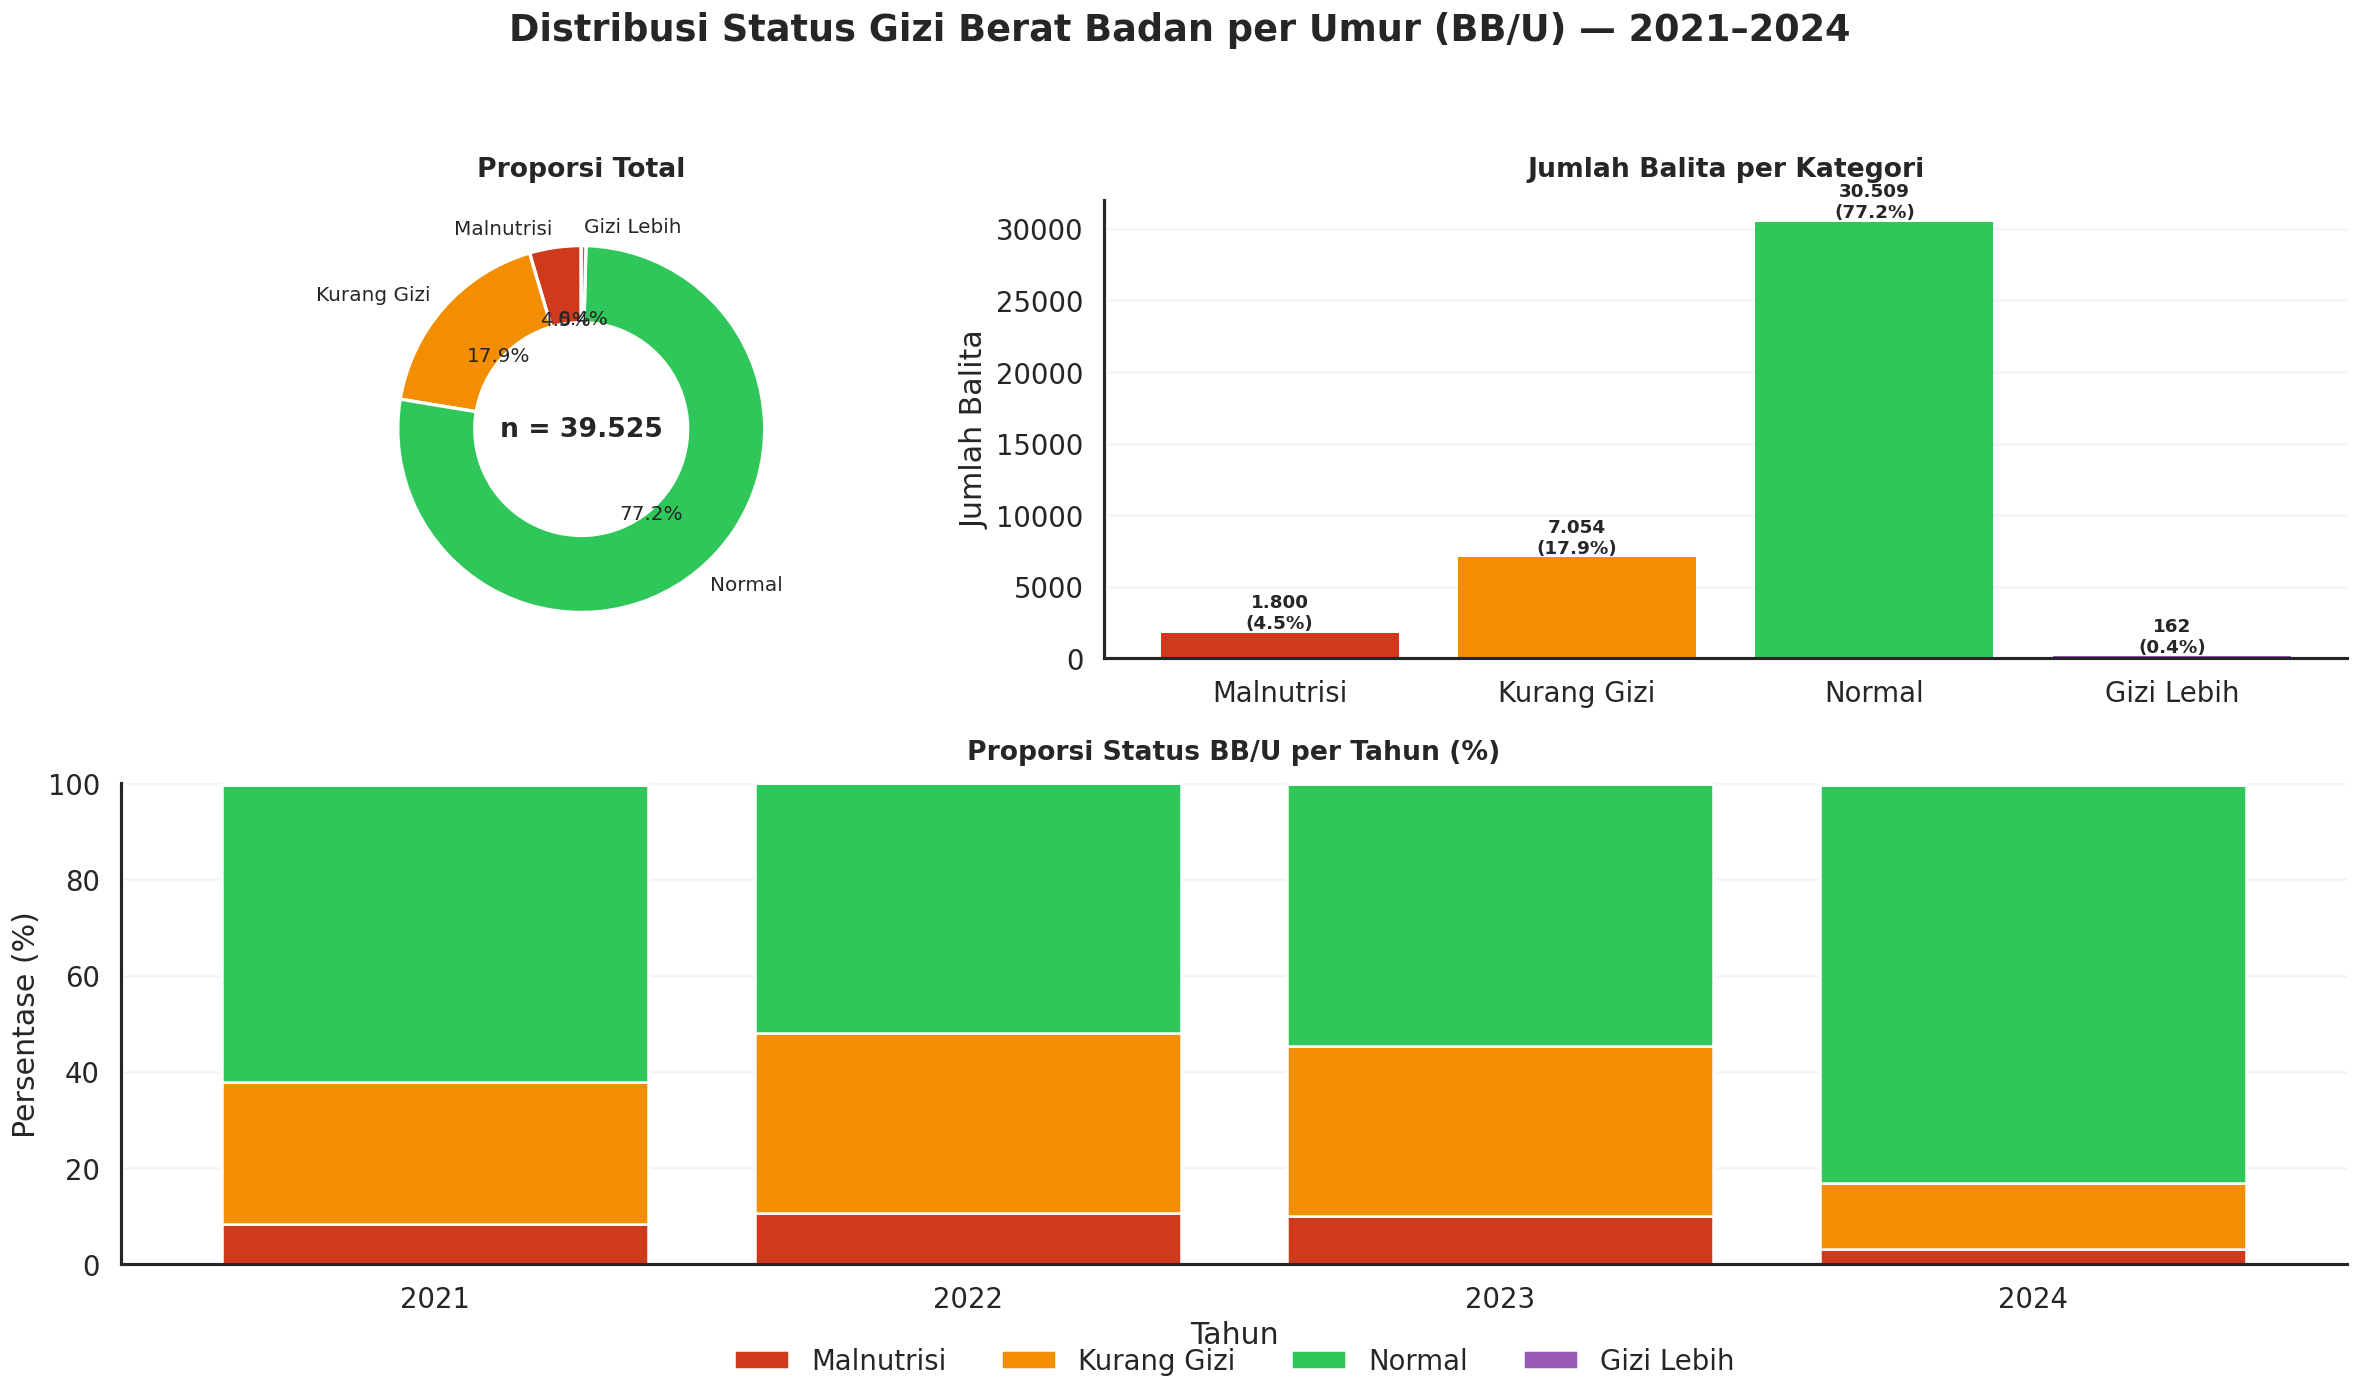

In [43]:
# Distribusi status BB/U total dan per tahun
wfa_count = df_clean["WFA_Status"].value_counts().reindex(WFA_ORDER).fillna(0).astype(int)
wfa_percent = (wfa_count / wfa_count.sum() * 100).round(2)
labels_id = [WFA_LABEL_MAP[i] for i in WFA_ORDER]
colors = [WFA_COLORS[i] for i in WFA_ORDER]

wfa_year_prop = pd.crosstab(
    df_clean["Tahun"],
    df_clean["WFA_Status"],
    normalize="index"
).reindex(columns=WFA_ORDER).fillna(0) * 100

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], width_ratios=[1, 1.35])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

fig.suptitle(
    "Distribusi Status Gizi Berat Badan per Umur (BB/U) — 2021–2024",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# Donut chart proporsi total
wedges, texts, autotexts = ax0.pie(
    wfa_percent,
    labels=labels_id,
    autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.42},
    textprops={"fontsize": 12}
)
ax0.text(0, 0, f"n = {wfa_count.sum():,}".replace(",", "."), ha="center", va="center", fontsize=16, fontweight="bold")
ax0.set_title("Proporsi Total", fontsize=16, pad=14)

# Bar jumlah total
bars = ax1.bar(labels_id, wfa_count.values, color=colors, edgecolor="none")
ax1.set_title("Jumlah Balita per Kategori", fontsize=16, pad=14)
ax1.set_ylabel("Jumlah Balita")
ax1.grid(axis="y", alpha=0.2)
for bar, pct in zip(bars, wfa_percent.values):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}\n({pct:.1f}%)".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Stacked bar per tahun
bottom = np.zeros(len(wfa_year_prop))
x = wfa_year_prop.index.astype(str)
for status, label, color in zip(WFA_ORDER, labels_id, colors):
    values = wfa_year_prop[status].values
    ax2.bar(x, values, bottom=bottom, label=label, color=color, edgecolor="white")
    bottom += values

ax2.set_title("Proporsi Status BB/U per Tahun (%)", fontsize=16, pad=14)
ax2.set_xlabel("Tahun")
ax2.set_ylabel("Persentase (%)")
ax2.set_ylim(0, 100)
ax2.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
ax2.grid(axis="y", alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig("viz1_distribusi_status_bbu_2021_2024.png")
plt.show()

mayoritas balita pada periode 2021–2024 berada dalam kategori Normal berdasarkan indikator BB/U, yaitu sebanyak 30.509 balita atau 77,2%. Namun, masih terdapat proporsi balita dengan status Kurang Gizi sebesar 17,9%, Malnutrisi sebesar 4,5%, dan Gizi Lebih sebesar 0,4%.

Jika dilihat berdasarkan tahun, proporsi status BB/U mengalami variasi. Tahun 2022 dan 2023 terlihat memiliki proporsi balita dengan Kurang Gizi yang cukup besar dibandingkan tahun lain. Sementara itu, tahun 2024 menunjukkan proporsi Normal yang lebih tinggi. Hal ini mengindikasikan bahwa meskipun kondisi gizi mayoritas balita tergolong normal, masalah kekurangan gizi masih muncul secara konsisten selama periode 2021–2024.

### 6.2 Distribusi Z-Score per Jenis Kelamin

Gambar berhasil disimpan: visualisasi_output/viz2_distribusi_zscore_gender_2021_2024.png


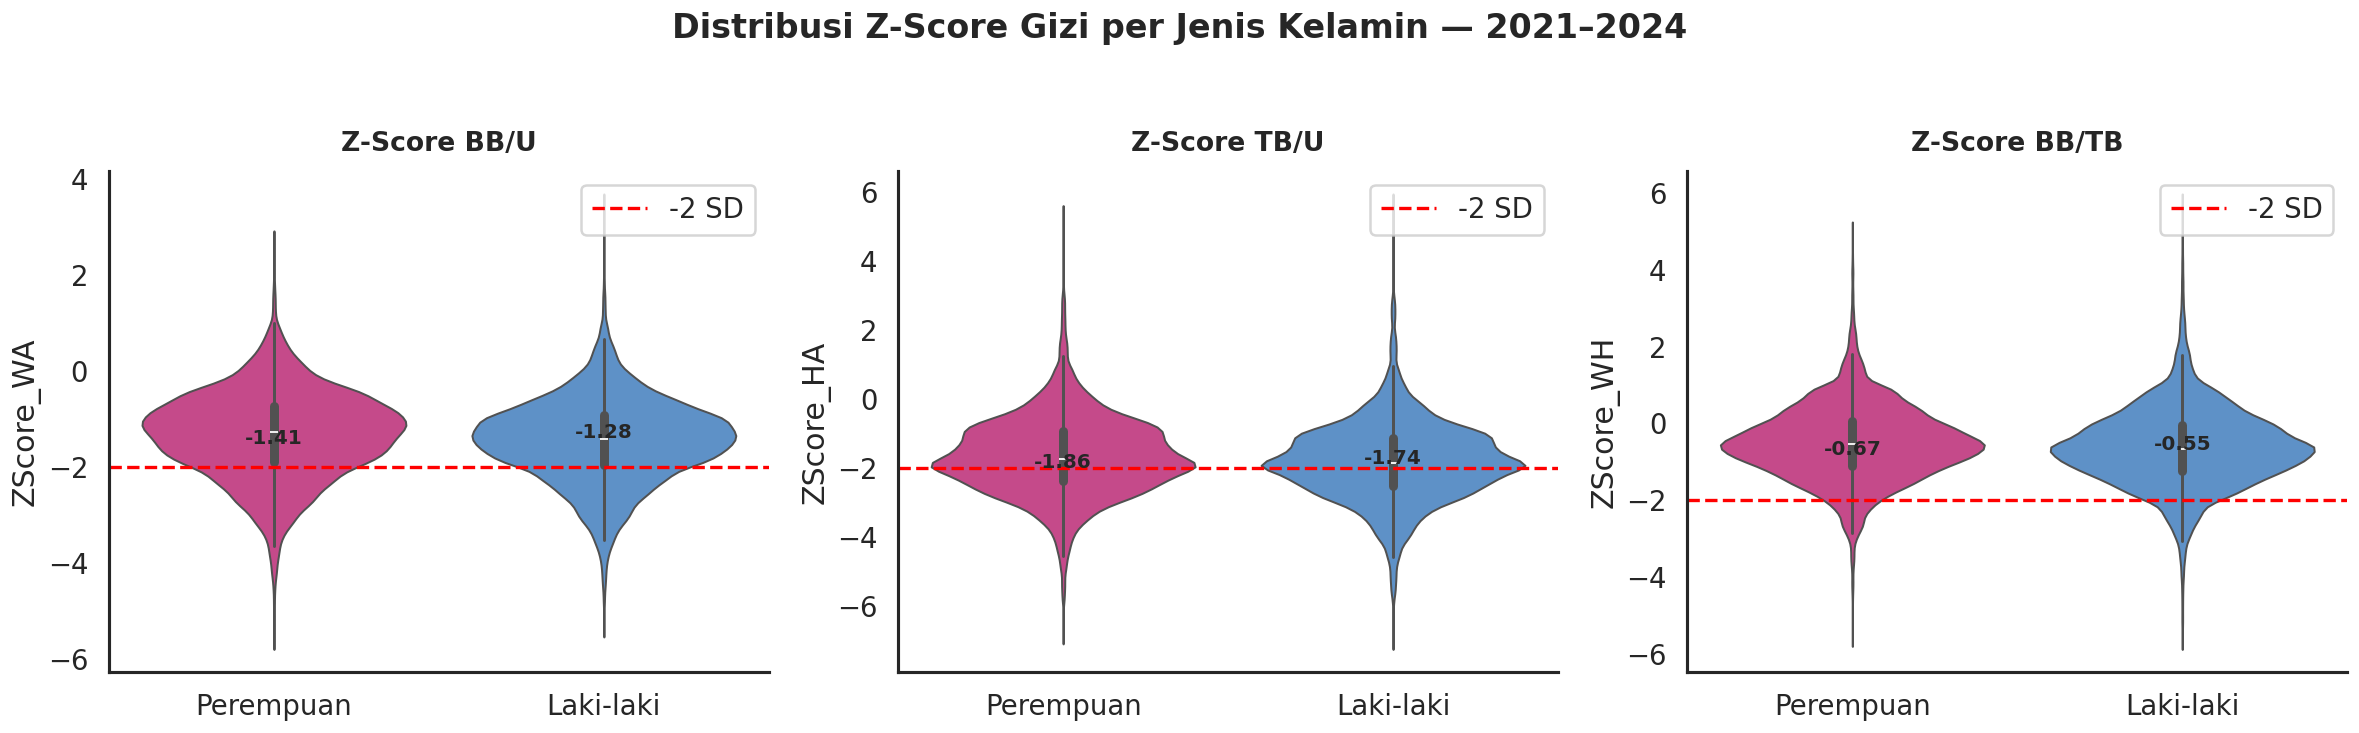

In [ ]:
zscore_info = [
    ("ZScore_WA", "Z-Score BB/U"),
    ("ZScore_HA", "Z-Score TB/U"),
    ("ZScore_WH", "Z-Score BB/TB")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Distribusi Z-Score Gizi per Jenis Kelamin — 2021–2024", fontsize=20, fontweight="bold", y=1.03)

palette_gender = {"Laki-laki": COLOR_BLUE, "Perempuan": COLOR_PINK}

for ax, (col, title) in zip(axes, zscore_info):
    sns.violinplot(
        data=df_clean,
        x="Gender_Label",
        y=col,
        ax=ax,
        palette=palette_gender,
        inner="box",
        linewidth=1.2,
        cut=0
    )

    ax.axhline(-2, color="red", linestyle="--", linewidth=2, label="-2 SD")

    medians = df_clean.groupby("Gender_Label")[col].median()
    for i, gender in enumerate(["Laki-laki", "Perempuan"]):
        if gender in medians.index:
            median_value = medians.loc[gender]
            ax.text(i, median_value, f"{median_value:.2f}", ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
save_fig("viz2_distribusi_zscore_gender_2021_2024.png")
plt.show()

Pada indikator BB/U, rata-rata Z-Score perempuan adalah sekitar -1,41, sedangkan laki-laki sekitar -1,28. Pada indikator TB/U, perempuan memiliki rata-rata sekitar -1,86, sedangkan laki-laki sekitar -1,74. Pada indikator BB/TB, perempuan memiliki rata-rata sekitar -0,67, sedangkan laki-laki sekitar -0,55.

Artinya, balita perempuan cenderung memiliki nilai rata-rata Z-Score yang sedikit lebih rendah dibandingkan laki-laki pada ketiga indikator.

### 6.3 Rata-rata Z-Score TB/U Berdasarkan Kelompok Usia

Gambar berhasil disimpan: visualisasi_output/viz3_zscore_tbu_kelompok_usia_2021_2024.png


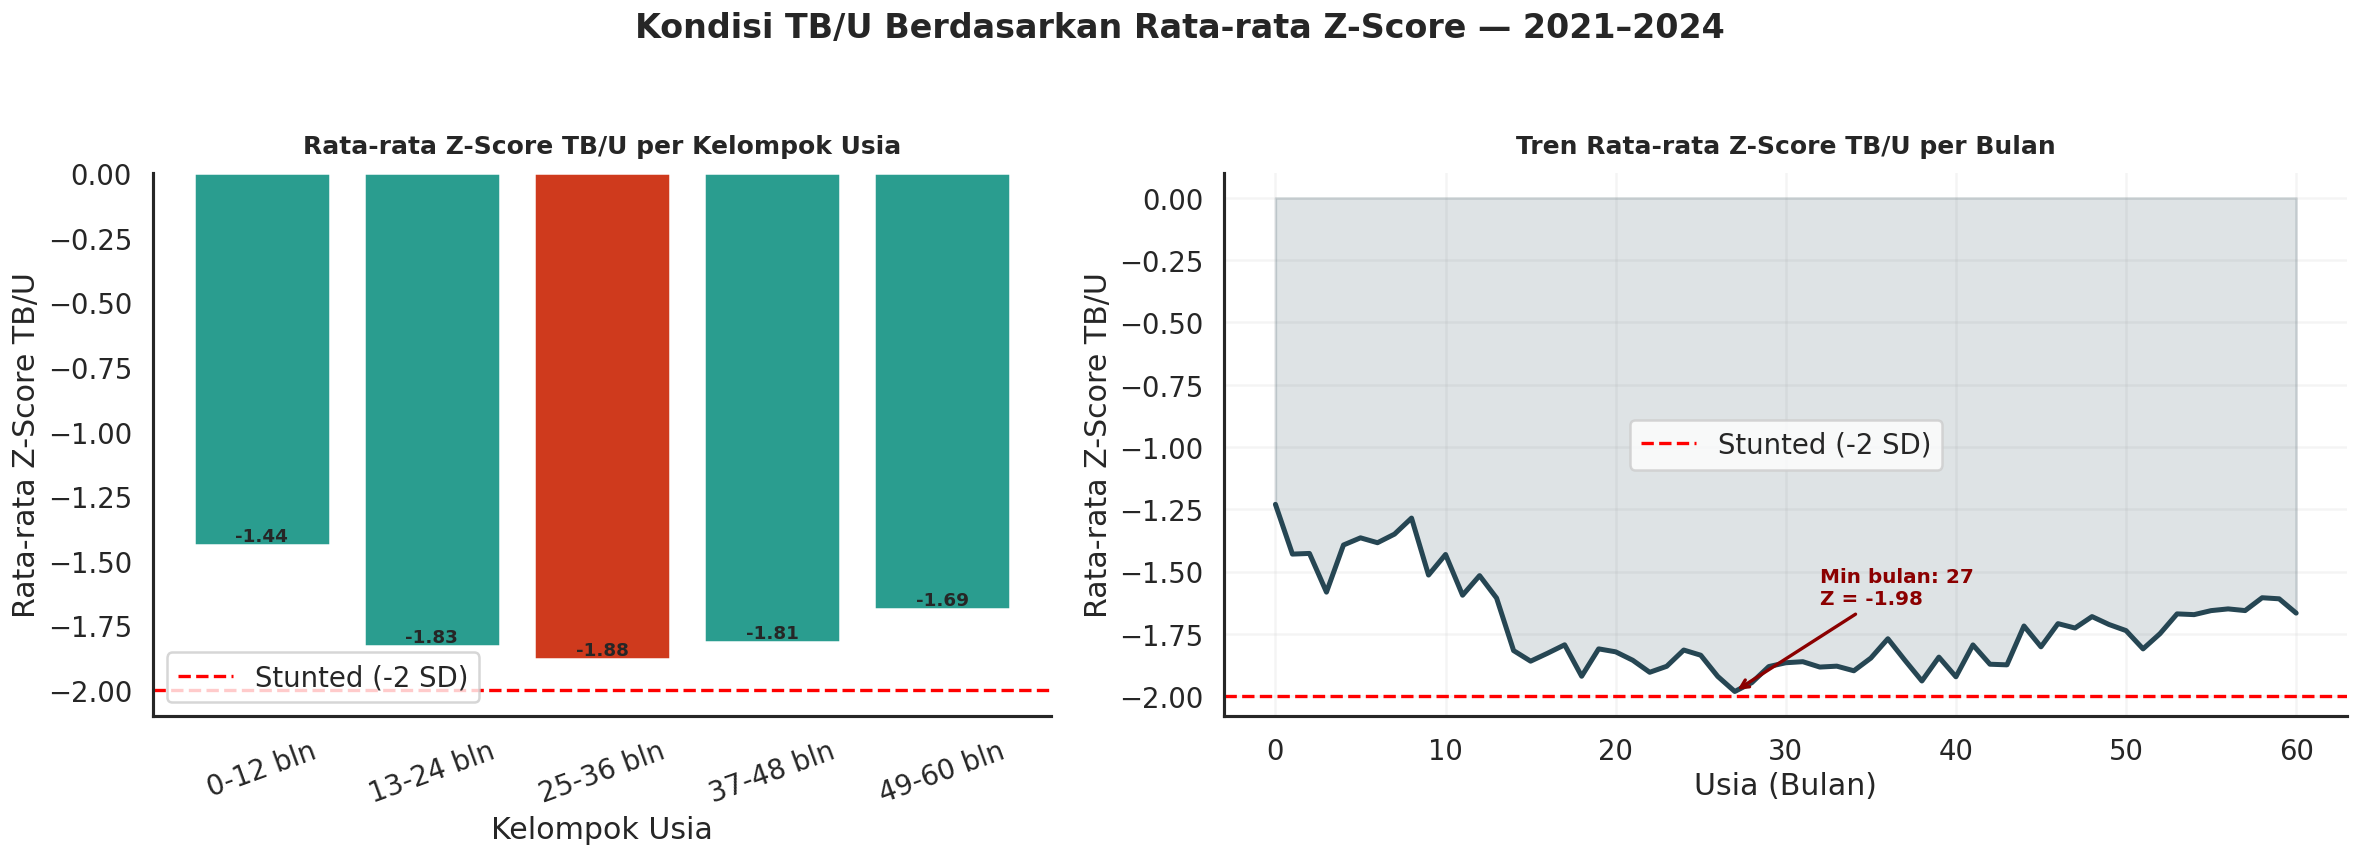

Kelompok usia dengan rata-rata Z-Score TB/U terendah:
25-36 bln dengan rata-rata Z-Score TB/U -1.879


In [45]:
# Rata-rata Z-Score TB/U berdasarkan kelompok usia dan usia bulan
hfa_age_group = (
    df_clean
    .groupby("Age_Group_Short", observed=True)["ZScore_HA"]
    .mean()
    .reset_index()
)

monthly_hfa = (
    df_clean
    .groupby("Age_Month")["ZScore_HA"]
    .mean()
    .reset_index()
    .sort_values("Age_Month")
)

min_group = hfa_age_group.loc[hfa_age_group["ZScore_HA"].idxmin()]
min_month = monthly_hfa.loc[monthly_hfa["ZScore_HA"].idxmin()]

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1.25]})
fig.suptitle("Kondisi TB/U Berdasarkan Rata-rata Z-Score — 2021–2024", fontsize=20, fontweight="bold", y=1.03)

bars = axes[0].bar(
    hfa_age_group["Age_Group_Short"].astype(str),
    hfa_age_group["ZScore_HA"],
    color=[COLOR_RED if x == min_group["Age_Group_Short"] else COLOR_TEAL for x in hfa_age_group["Age_Group_Short"]]
)
axes[0].axhline(-2, color="red", linestyle="--", linewidth=2, label="Stunted (-2 SD)")
axes[0].set_title("Rata-rata Z-Score TB/U per Kelompok Usia", fontsize=15, pad=12)
axes[0].set_xlabel("Kelompok Usia")
axes[0].set_ylabel("Rata-rata Z-Score TB/U")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()
for bar in bars:
    value = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[1].plot(monthly_hfa["Age_Month"], monthly_hfa["ZScore_HA"], color=COLOR_NAVY, linewidth=3)
axes[1].fill_between(monthly_hfa["Age_Month"], monthly_hfa["ZScore_HA"], 0, color=COLOR_NAVY, alpha=0.15)
axes[1].axhline(-2, color="red", linestyle="--", linewidth=2, label="Stunted (-2 SD)")
axes[1].set_title("Tren Rata-rata Z-Score TB/U per Bulan", fontsize=15, pad=12)
axes[1].set_xlabel("Usia (Bulan)")
axes[1].set_ylabel("Rata-rata Z-Score TB/U")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="center")
axes[1].annotate(
    f"Min bulan: {int(min_month['Age_Month'])}\nZ = {min_month['ZScore_HA']:.2f}",
    xy=(min_month["Age_Month"], min_month["ZScore_HA"]),
    xytext=(min_month["Age_Month"] + 5, min_month["ZScore_HA"] + 0.35),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=2),
    fontsize=12,
    color="darkred",
    fontweight="bold"
)

plt.tight_layout()
save_fig("viz3_zscore_tbu_kelompok_usia_2021_2024.png")
plt.show()

print("Kelompok usia dengan rata-rata Z-Score TB/U terendah:")
print(f"{min_group['Age_Group_Short']} dengan rata-rata Z-Score TB/U {min_group['ZScore_HA']:.3f}")


kelompok usia dengan rata-rata Z-Score TB/U terendah adalah kelompok usia 25–36 bulan, dengan nilai sekitar -1,88. Nilai ini mendekati ambang batas stunted, yaitu -2 SD.

Pola ini menunjukkan bahwa risiko gangguan pertumbuhan linear atau stunting cenderung lebih kuat pada kelompok usia 25–36 bulan. Pada grafik tren bulanan, titik terendah juga terlihat berada di sekitar usia 27 bulan, dengan rata-rata Z-Score TB/U sekitar -1,98. Hal ini memperkuat bahwa rentang usia sekitar 2–3 tahun merupakan periode yang cukup rentan terhadap masalah TB/U.

### 6.4 Tren Pertumbuhan Berat dan Tinggi Badan Berdasarkan Usia Bulan

Gambar berhasil disimpan: visualisasi_output/viz4_tren_pertumbuhan_berat_tinggi_2021_2024.png


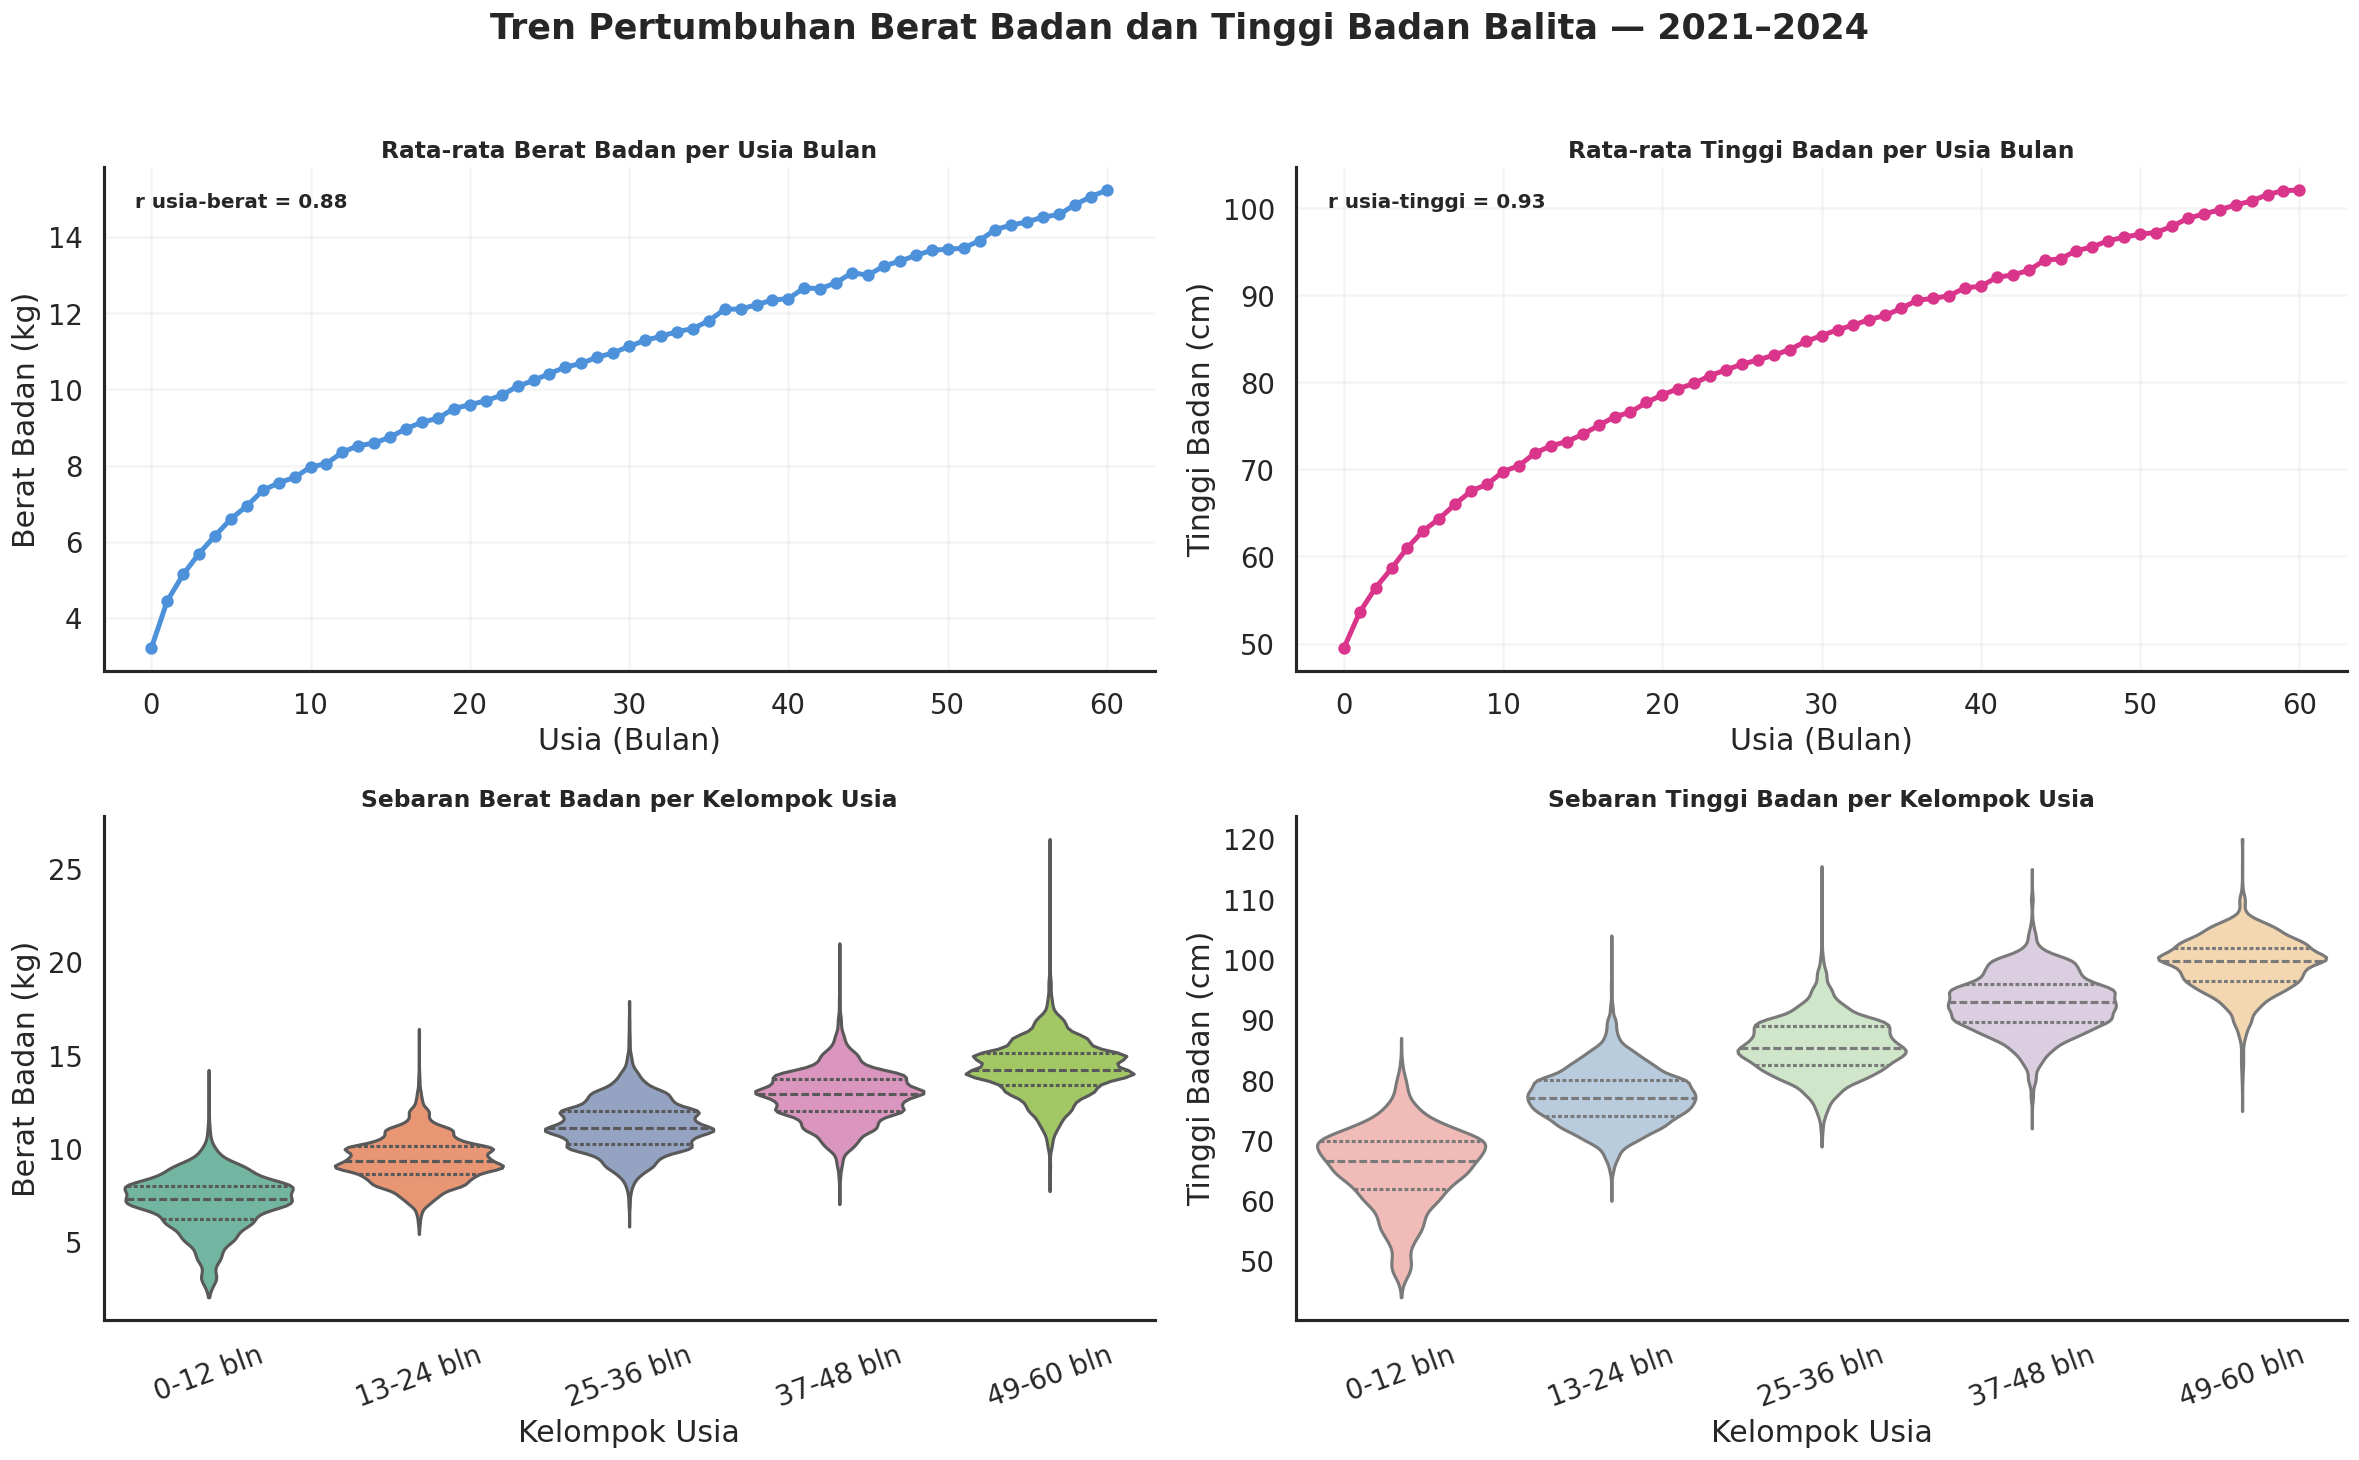

In [46]:
# Tren rata-rata berat badan dan tinggi badan berdasarkan usia bulan
trend_growth = (
    df_clean
    .groupby("Age_Month")[["Weight", "Height"]]
    .mean()
    .reset_index()
    .sort_values("Age_Month")
)

r_weight = df_clean["Age_Month"].corr(df_clean["Weight"])
r_height = df_clean["Age_Month"].corr(df_clean["Height"])

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle("Tren Pertumbuhan Berat Badan dan Tinggi Badan Balita — 2021–2024", fontsize=21, fontweight="bold", y=1.02)

# Line tren rata-rata berat badan
axes[0, 0].plot(trend_growth["Age_Month"], trend_growth["Weight"], color=COLOR_BLUE, linewidth=3)
axes[0, 0].scatter(trend_growth["Age_Month"], trend_growth["Weight"], color=COLOR_BLUE, s=35)
axes[0, 0].set_title("Rata-rata Berat Badan per Usia Bulan", fontsize=14)
axes[0, 0].set_xlabel("Usia (Bulan)")
axes[0, 0].set_ylabel("Berat Badan (kg)")
axes[0, 0].grid(alpha=0.2)
axes[0, 0].text(0.03, 0.92, f"r usia-berat = {r_weight:.2f}", transform=axes[0, 0].transAxes, fontsize=12, fontweight="bold")

# Line tren rata-rata tinggi badan
axes[0, 1].plot(trend_growth["Age_Month"], trend_growth["Height"], color=COLOR_PINK, linewidth=3)
axes[0, 1].scatter(trend_growth["Age_Month"], trend_growth["Height"], color=COLOR_PINK, s=35)
axes[0, 1].set_title("Rata-rata Tinggi Badan per Usia Bulan", fontsize=14)
axes[0, 1].set_xlabel("Usia (Bulan)")
axes[0, 1].set_ylabel("Tinggi Badan (cm)")
axes[0, 1].grid(alpha=0.2)
axes[0, 1].text(0.03, 0.92, f"r usia-tinggi = {r_height:.2f}", transform=axes[0, 1].transAxes, fontsize=12, fontweight="bold")

# Violin berat badan per kelompok usia
sns.violinplot(
    data=df_clean,
    x="Age_Group_Short",
    y="Weight",
    ax=axes[1, 0],
    palette="Set2",
    inner="quartile",
    cut=0
)
axes[1, 0].set_title("Sebaran Berat Badan per Kelompok Usia", fontsize=14)
axes[1, 0].set_xlabel("Kelompok Usia")
axes[1, 0].set_ylabel("Berat Badan (kg)")
axes[1, 0].tick_params(axis="x", rotation=20)

# Violin tinggi badan per kelompok usia
sns.violinplot(
    data=df_clean,
    x="Age_Group_Short",
    y="Height",
    ax=axes[1, 1],
    palette="Pastel1",
    inner="quartile",
    cut=0
)
axes[1, 1].set_title("Sebaran Tinggi Badan per Kelompok Usia", fontsize=14)
axes[1, 1].set_xlabel("Kelompok Usia")
axes[1, 1].set_ylabel("Tinggi Badan (cm)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_fig("viz4_tren_pertumbuhan_berat_tinggi_2021_2024.png")
plt.show()

rata-rata berat badan dan tinggi badan balita meningkat seiring bertambahnya usia bulan. Pola garis pada kedua grafik menunjukkan tren pertumbuhan yang naik secara konsisten dari usia 0 sampai 60 bulan.

Hubungan antara usia dan berat badan memiliki nilai korelasi sekitar 0,88, sedangkan hubungan antara usia dan tinggi badan memiliki nilai korelasi sekitar 0,93. Ini menunjukkan bahwa hubungan usia dengan berat badan dan tinggi badan termasuk sangat kuat dan positif.

Pada bagian violin plot, terlihat bahwa sebaran berat badan dan tinggi badan juga semakin meningkat pada kelompok usia yang lebih tua. Kelompok usia 49–60 bulan memiliki rata-rata berat badan dan tinggi badan paling tinggi dibandingkan kelompok usia lainnya.

### 6.5 Prevalensi Wasting Berdasarkan BB/TB, Kelompok Usia, dan Gender

Gambar berhasil disimpan: visualisasi_output/viz5_prevalensi_wasting_2021_2024.png


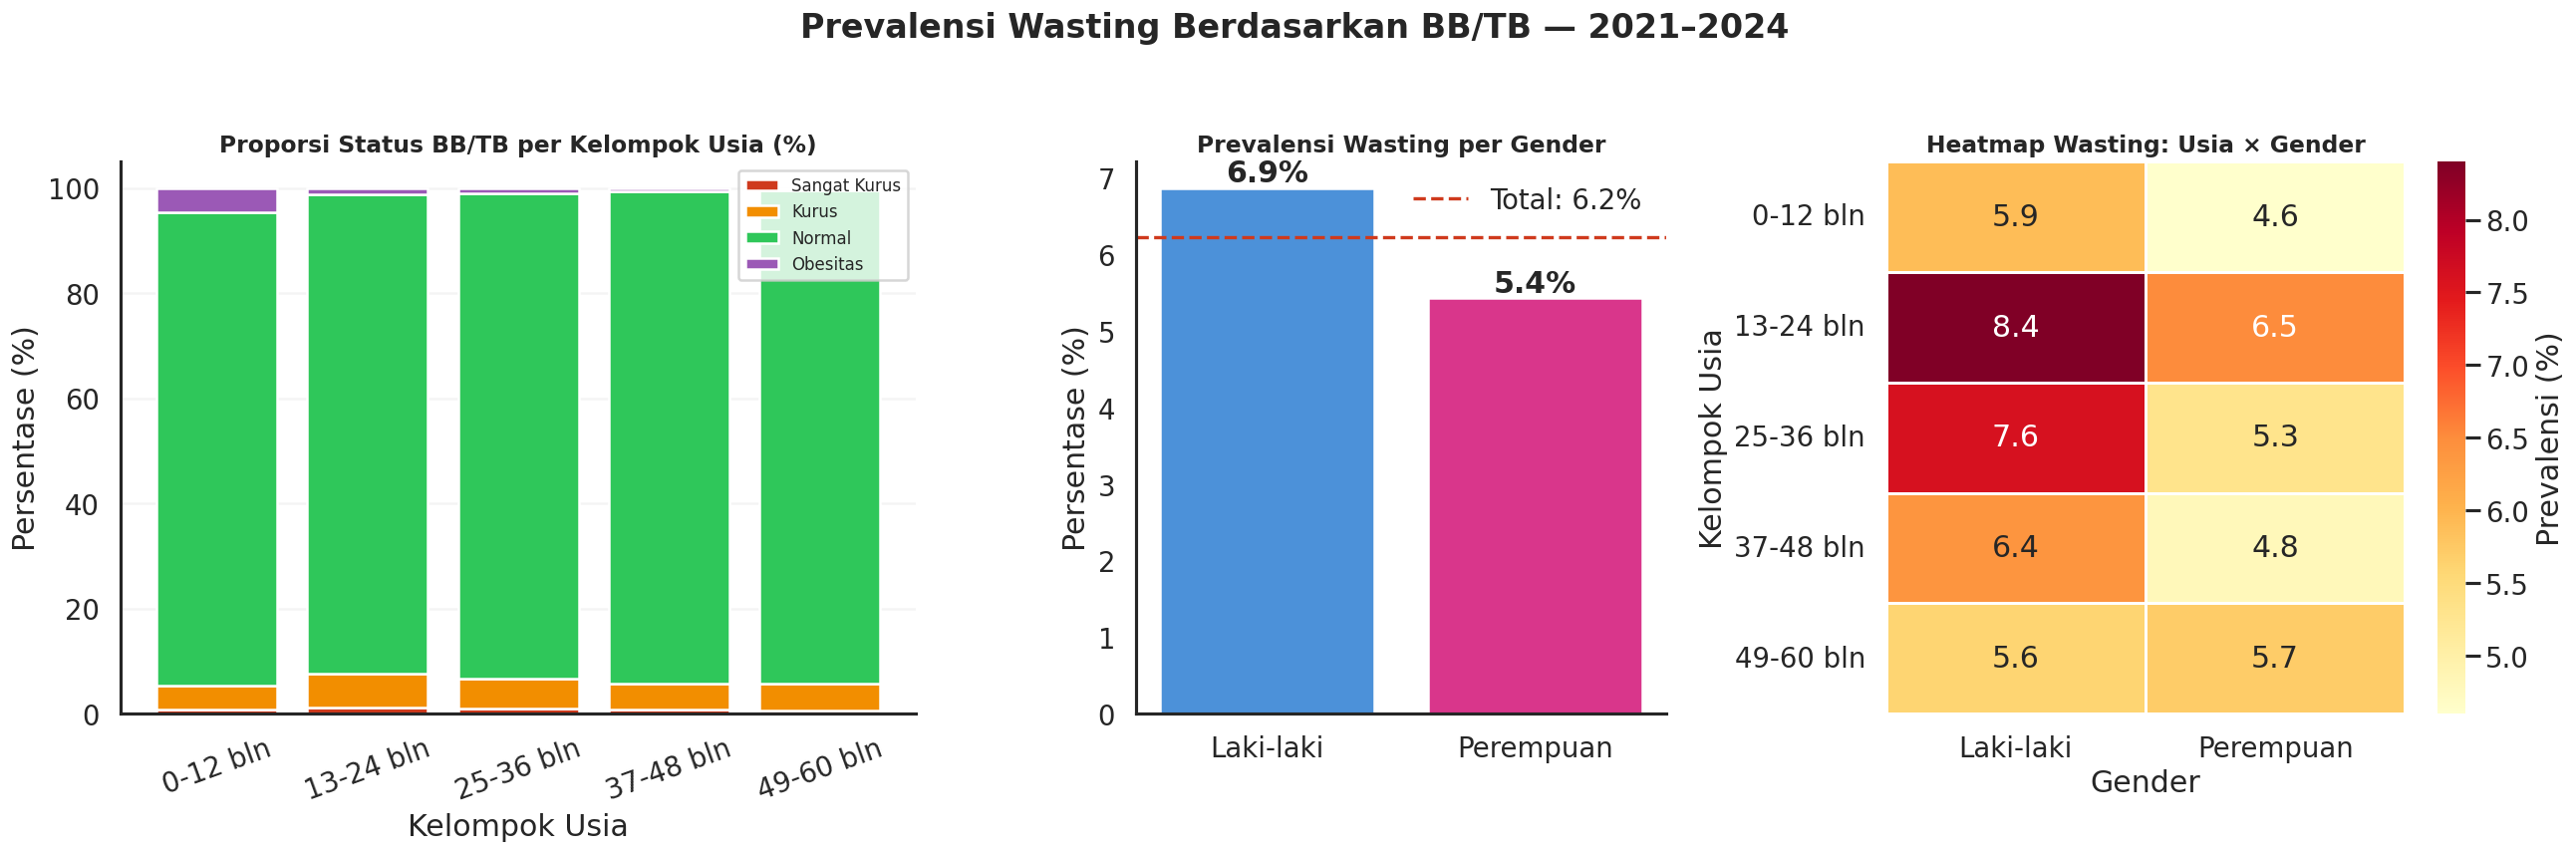

Prevalensi wasting total: 6.22%
Kelompok dengan prevalensi wasting tertinggi:
13-24 bulan - Laki-laki (8.45%)


In [47]:
# Prevalensi wasting total, per gender, dan per kombinasi kelompok usia-gender
wfh_age_prop = pd.crosstab(
    df_clean["Age_Group_Short"],
    df_clean["WFH_Status"],
    normalize="index"
).reindex(columns=WFH_ORDER).fillna(0) * 100

wasting_total = df_clean["Is_Wasting"].mean() * 100
wasting_gender = (
    df_clean
    .groupby("Gender_Label")["Is_Wasting"]
    .mean()
    .mul(100)
    .reindex(["Laki-laki", "Perempuan"])
    .round(2)
)

wasting_heatmap = (
    df_clean
    .groupby(["Age_Group_Short", "Gender_Label"], observed=True)["Is_Wasting"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(columns=["Laki-laki", "Perempuan"])
    .round(1)
)

max_wasting = (
    df_clean
    .groupby(["Age_Group", "Gender_Label"], observed=True)["Is_Wasting"]
    .mean()
    .mul(100)
    .reset_index(name="Prevalensi Wasting (%)")
    .sort_values("Prevalensi Wasting (%)", ascending=False)
    .iloc[0]
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={"width_ratios": [1.35, 0.9, 1.1]})
fig.suptitle("Prevalensi Wasting Berdasarkan BB/TB — 2021–2024", fontsize=20, fontweight="bold", y=1.03)

# Stacked bar proporsi BB/TB per usia
bottom = np.zeros(len(wfh_age_prop))
for status in WFH_ORDER:
    values = wfh_age_prop[status].values
    axes[0].bar(
        wfh_age_prop.index.astype(str),
        values,
        bottom=bottom,
        label=WFH_LABEL_MAP.get(status, status),
        color=WFH_COLORS[status],
        edgecolor="white"
    )
    bottom += values

axes[0].set_title("Proporsi Status BB/TB per Kelompok Usia (%)", fontsize=14)
axes[0].set_xlabel("Kelompok Usia")
axes[0].set_ylabel("Persentase (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(axis="y", alpha=0.2)

# Bar wasting per gender
bars = axes[1].bar(wasting_gender.index, wasting_gender.values, color=[COLOR_BLUE, COLOR_PINK])
axes[1].axhline(wasting_total, color=COLOR_RED, linestyle="--", linewidth=2, label=f"Total: {wasting_total:.1f}%")
axes[1].set_title("Prevalensi Wasting per Gender", fontsize=14)
axes[1].set_ylabel("Persentase (%)")
axes[1].legend(frameon=False)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:.1f}%", ha="center", va="bottom", fontweight="bold")

# Heatmap wasting usia x gender
sns.heatmap(
    wasting_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=1.5,
    linecolor="white",
    ax=axes[2],
    cbar_kws={"label": "Prevalensi (%)"}
)
axes[2].set_title("Heatmap Wasting: Usia × Gender", fontsize=14)
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Kelompok Usia")

plt.tight_layout()
save_fig("viz5_prevalensi_wasting_2021_2024.png")
plt.show()

print(f"Prevalensi wasting total: {wasting_total:.2f}%")
print("Kelompok dengan prevalensi wasting tertinggi:")
print(f"{max_wasting['Age_Group']} - {max_wasting['Gender_Label']} ({max_wasting['Prevalensi Wasting (%)']:.2f}%)")

prevalensi wasting berdasarkan indikator BB/TB. Secara total, prevalensi wasting berada pada angka sekitar 6,2%. Berdasarkan jenis kelamin, balita laki-laki memiliki prevalensi wasting lebih tinggi, yaitu sekitar 6,9%, sedangkan perempuan sekitar 5,4%.

Jika dilihat berdasarkan kombinasi kelompok usia dan gender, prevalensi wasting tertinggi terdapat pada kelompok laki-laki usia 13–24 bulan, yaitu sekitar 8,4%. Kelompok laki-laki usia 25–36 bulan juga cukup tinggi, yaitu sekitar 7,6%. Hal ini menunjukkan bahwa balita laki-laki, khususnya pada usia 13–24 bulan, menjadi kelompok yang lebih rentan terhadap wasting.

### 6.6 Heatmap Korelasi Variabel Numerik

Gambar berhasil disimpan: visualisasi_output/viz6_heatmap_korelasi_2021_2024.png


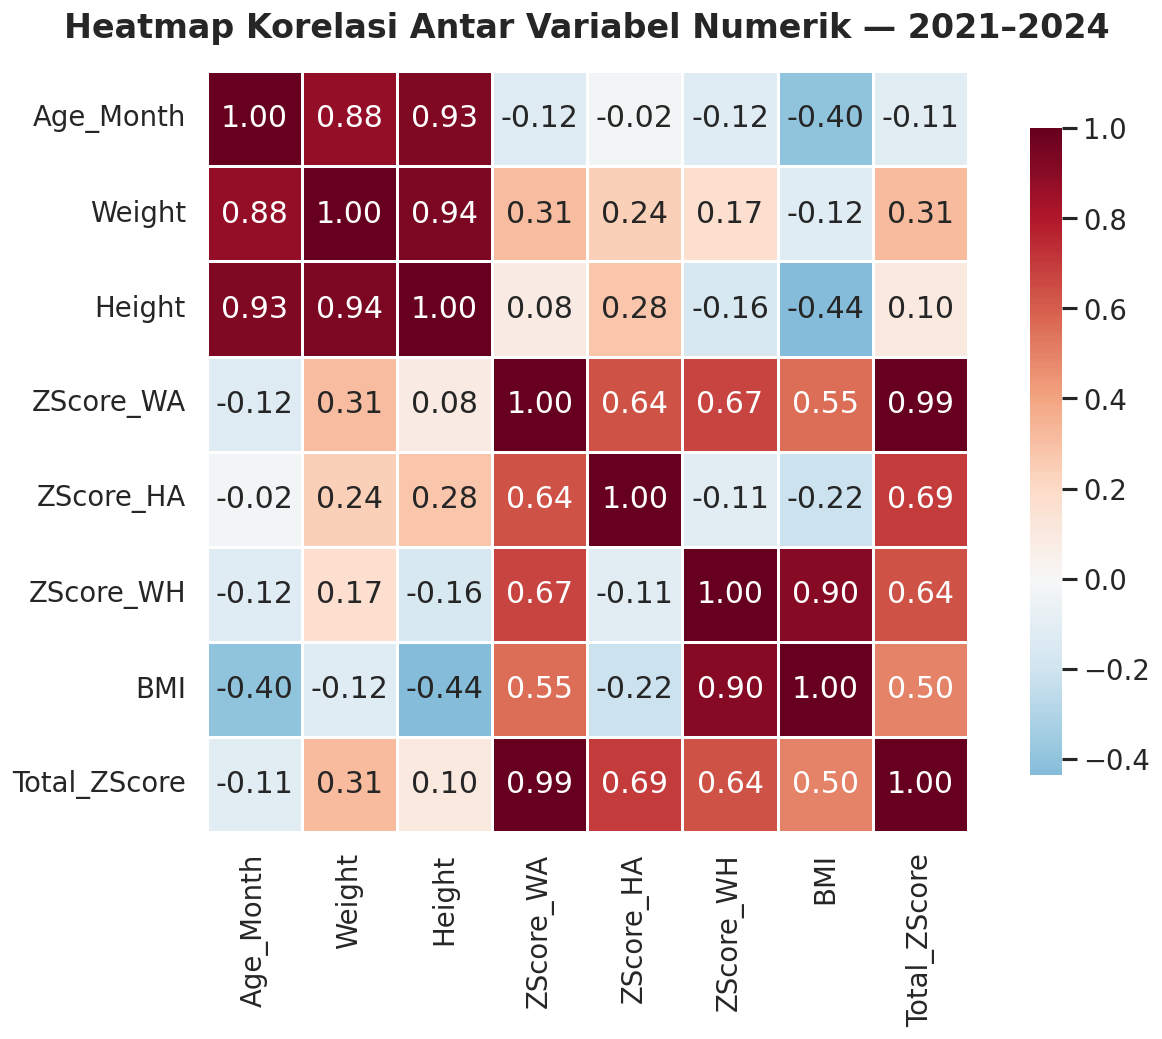

In [48]:
corr_cols = [
    "Age_Month",
    "Weight",
    "Height",
    "ZScore_WA",
    "ZScore_HA",
    "ZScore_WH",
    "BMI",
    "Total_ZScore"
]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 9))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.85}
)

plt.title("Heatmap Korelasi Antar Variabel Numerik — 2021–2024", fontsize=20, fontweight="bold", pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
save_fig("viz6_heatmap_korelasi_2021_2024.png")
plt.show()

Korelasi usia dengan berat badan sebesar 0,88, sedangkan korelasi usia dengan tinggi badan sebesar 0,93. Artinya, semakin bertambah usia balita, berat badan dan tinggi badan cenderung meningkat.

Korelasi antara berat badan dan tinggi badan juga sangat kuat, yaitu 0,94. Selain itu, Z-Score BB/TB memiliki korelasi tinggi dengan BMI, yaitu 0,90, yang menunjukkan bahwa status BB/TB sangat berkaitan dengan proporsi berat terhadap tinggi badan. Sementara itu, usia memiliki korelasi negatif dengan BMI sebesar -0,40, yang menunjukkan bahwa BMI cenderung menurun relatif terhadap pertambahan usia.

### 6.7 Distribusi Z-Score Histogram + KDE

Gambar berhasil disimpan: visualisasi_output/viz7_histogram_zscore_2021_2024.png


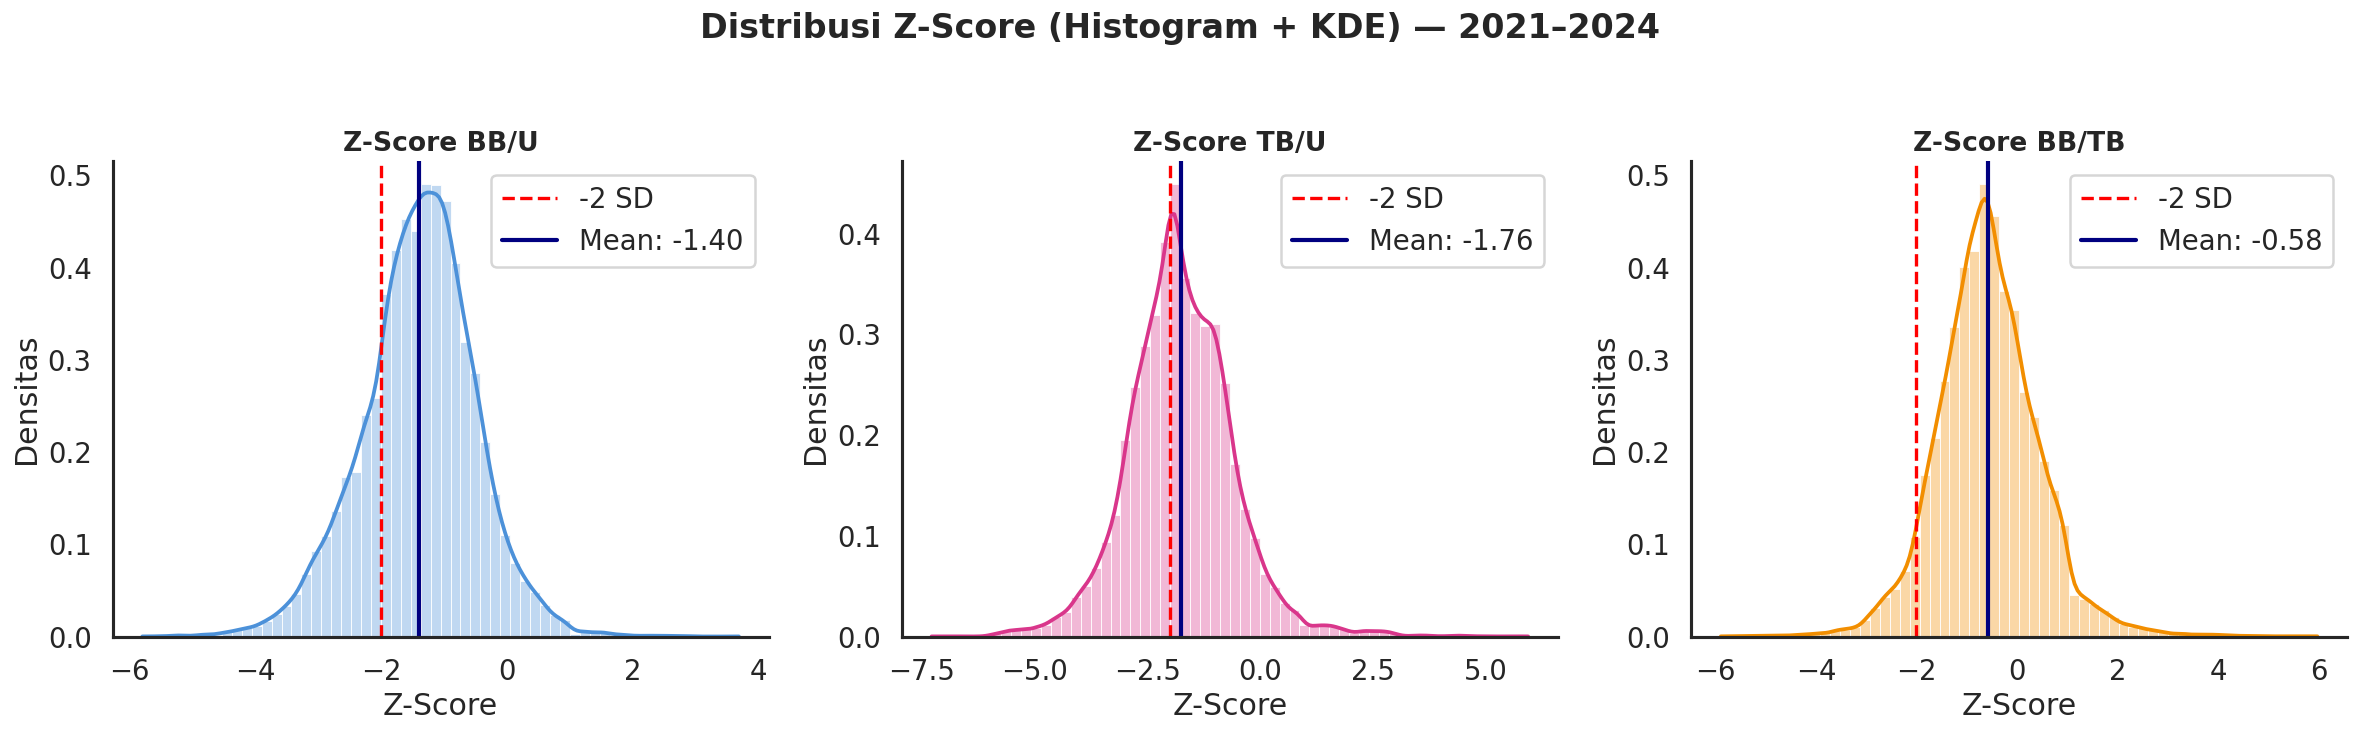

In [49]:
zscore_plots = [
    ("ZScore_WA", "Z-Score BB/U", COLOR_BLUE),
    ("ZScore_HA", "Z-Score TB/U", COLOR_PINK),
    ("ZScore_WH", "Z-Score BB/TB", COLOR_ORANGE)
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Distribusi Z-Score (Histogram + KDE) — 2021–2024", fontsize=20, fontweight="bold", y=1.03)

for ax, (col, title, color) in zip(axes, zscore_plots):
    mean_value = df_clean[col].mean()
    sns.histplot(df_clean[col], bins=60, kde=True, stat="density", color=color, alpha=0.35, ax=ax)
    ax.axvline(-2, color="red", linestyle="--", linewidth=2, label="-2 SD")
    ax.axvline(mean_value, color="navy", linewidth=2.5, label=f"Mean: {mean_value:.2f}")
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Z-Score")
    ax.set_ylabel("Densitas")
    ax.legend()

plt.tight_layout()
save_fig("viz7_histogram_zscore_2021_2024.png")
plt.show()

Score BB/U adalah sekitar -1,40, rata-rata Z-Score TB/U sekitar -1,76, dan rata-rata Z-Score BB/TB sekitar -0,58.

Dari ketiga indikator tersebut, nilai rata-rata TB/U adalah yang paling rendah dan paling mendekati batas -2 SD. Hal ini menunjukkan bahwa masalah pertumbuhan linear atau stunting lebih menonjol dibandingkan masalah wasting. Sementara itu, indikator BB/TB memiliki rata-rata yang lebih dekat ke nilai normal, sehingga secara umum masalah wasting tidak sebesar masalah TB/U.

### 6.8 Double Burden dan Gizi Kritis

Gambar berhasil disimpan: visualisasi_output/viz8_double_burden_gizi_kritis_2021_2024.png


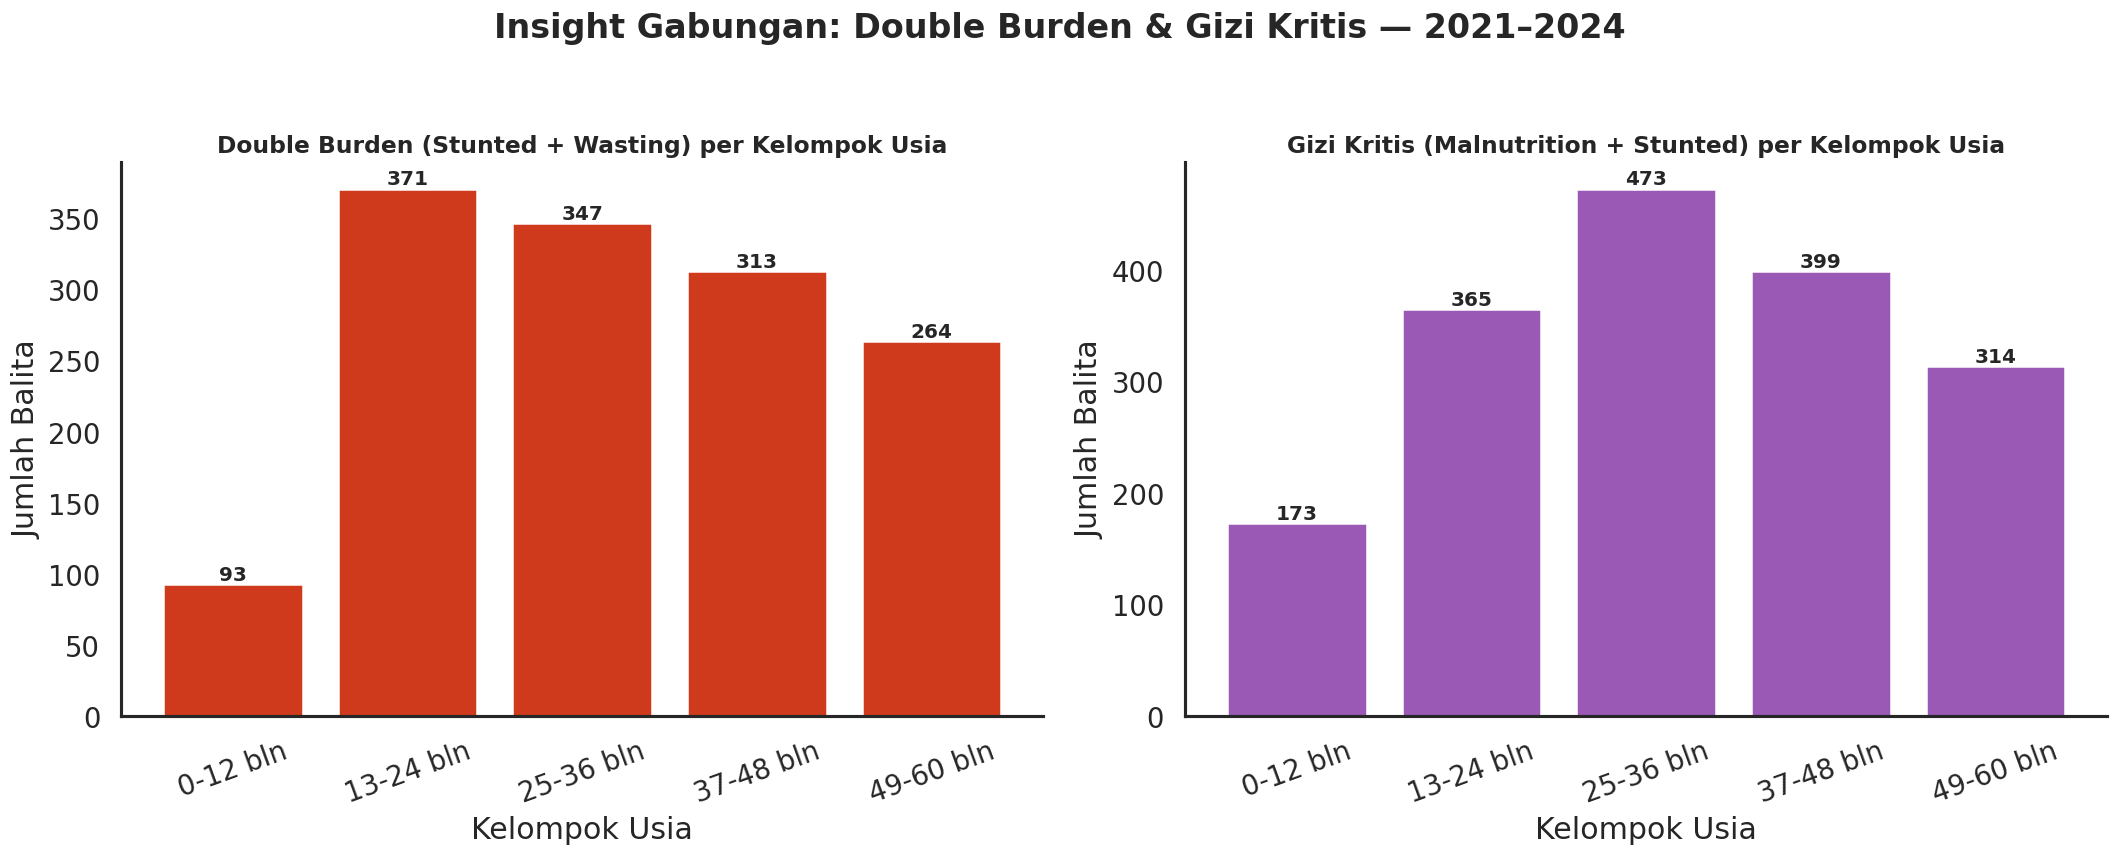

In [50]:
# Jumlah double burden dan gizi kritis per kelompok usia
double_burden_age = df_clean.groupby("Age_Group_Short", observed=True)["Double_Burden"].sum()
gizi_kritis_age = df_clean.groupby("Age_Group_Short", observed=True)["Gizi_Kritis"].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Insight Gabungan: Double Burden & Gizi Kritis — 2021–2024", fontsize=20, fontweight="bold", y=1.03)

bars1 = axes[0].bar(double_burden_age.index.astype(str), double_burden_age.values, color=COLOR_RED)
axes[0].set_title("Double Burden (Stunted + Wasting) per Kelompok Usia", fontsize=14)
axes[0].set_xlabel("Kelompok Usia")
axes[0].set_ylabel("Jumlah Balita")
axes[0].tick_params(axis="x", rotation=20)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:,.0f}".replace(",", "."), ha="center", va="bottom", fontsize=12, fontweight="bold")

bars2 = axes[1].bar(gizi_kritis_age.index.astype(str), gizi_kritis_age.values, color=COLOR_PURPLE)
axes[1].set_title("Gizi Kritis (Malnutrition + Stunted) per Kelompok Usia", fontsize=14)
axes[1].set_xlabel("Kelompok Usia")
axes[1].set_ylabel("Jumlah Balita")
axes[1].tick_params(axis="x", rotation=20)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:,.0f}".replace(",", "."), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
save_fig("viz8_double_burden_gizi_kritis_2021_2024.png")
plt.show()

Pada grafik double burden, jumlah tertinggi terdapat pada kelompok usia 13–24 bulan sebanyak 371 balita, diikuti usia 25–36 bulan sebanyak 347 balita.

Pada grafik gizi kritis, jumlah tertinggi terdapat pada kelompok usia 25–36 bulan sebanyak 473 balita, diikuti usia 37–48 bulan sebanyak 399 balita, dan usia 13–24 bulan sebanyak 365 balita. Hal ini menunjukkan bahwa usia 13–36 bulan merupakan periode penting yang perlu diperhatikan karena banyak balita mulai menunjukkan kombinasi masalah gizi pada rentang usia tersebut.

## 7. Analisis Statistik Lanjutan

### 7.1 Uji Chi-Square Gender terhadap Status BB/U, TB/U, dan BB/TB

In [51]:
# Uji Chi-Square untuk melihat apakah status gizi berbeda signifikan berdasarkan gender
indikator_status = {
    "BB/U": "WFA_Status",
    "TB/U": "HFA_Status",
    "BB/TB": "WFH_Status"
}

hasil_chi_square = []
contingency_tables = {}

for indikator, kolom in indikator_status.items():
    tabel = pd.crosstab(df_clean["Gender_Label"], df_clean[kolom])
    chi2, p_value, dof, expected = stats.chi2_contingency(tabel)

    hasil_chi_square.append({
        "Indikator": indikator,
        "Chi-Square": round(chi2, 4),
        "p-value": p_value,
        "df": dof,
        "Kesimpulan": "Berbeda signifikan" if p_value < 0.05 else "Tidak berbeda signifikan"
    })
    contingency_tables[indikator] = tabel

    print(f"\n=== {indikator} ===")
    display(tabel)
    print(f"Chi-Square: {chi2:.4f}")
    print(f"p-value: {p_value:.8f}")
    print("Kesimpulan:", "Berbeda signifikan" if p_value < 0.05 else "Tidak berbeda signifikan")

hasil_chi_square_df = pd.DataFrame(hasil_chi_square)
hasil_chi_square_df



=== BB/U ===


WFA_Status,Malnutrition,Normal,Overnutrition,Underfed
Gender_Label,,,,
Laki-laki,1075,16557,89,3999
Perempuan,725,13952,73,3055


Chi-Square: 30.9111
p-value: 0.00000089
Kesimpulan: Berbeda signifikan

=== TB/U ===


HFA_Status,Not Stunted,Stunted
Gender_Label,,
Laki-laki,12435,9285
Perempuan,10959,6846


Chi-Square: 74.6721
p-value: 0.00000000
Kesimpulan: Berbeda signifikan

=== BB/TB ===


WFH_Status,Normal,Obese,Thin,Very Thin
Gender_Label,,,,
Laki-laki,19935,292,1251,242
Perempuan,16637,202,850,116


Chi-Square: 47.3657
p-value: 0.00000000
Kesimpulan: Berbeda signifikan


,Indikator,Chi-Square,p-value,df,Kesimpulan
0,BB/U,30.9111,8.874946e-07,3,Berbeda signifikan
1,TB/U,74.6721,5.557714e-18,1,Berbeda signifikan
2,BB/TB,47.3657,2.905622e-10,3,Berbeda signifikan


Uji Chi-Square digunakan untuk menjawab pertanyaan kedua. Jika p-value kurang dari 0,05, maka terdapat perbedaan atau hubungan yang signifikan antara gender dan status gizi pada indikator tersebut. Analisis ini dilakukan untuk tiga indikator, yaitu BB/U, TB/U, dan BB/TB.

### 7.2 Ringkasan Prevalensi Wasting Berdasarkan Kelompok Usia dan Gender

In [52]:
# Tabel prevalensi wasting per kelompok usia dan gender
wasting_age_gender = (
    df_clean
    .groupby(["Age_Group", "Gender_Label"], observed=True)["Is_Wasting"]
    .agg(Jumlah_Data="count", Jumlah_Wasting="sum", Prevalensi=lambda x: x.mean() * 100)
    .reset_index()
)

wasting_age_gender["Prevalensi (%)"] = wasting_age_gender["Prevalensi"].round(2)
wasting_age_gender = wasting_age_gender.drop(columns="Prevalensi")
wasting_age_gender = wasting_age_gender.sort_values("Prevalensi (%)", ascending=False)

wasting_age_gender

,Age_Group,Gender_Label,Jumlah_Data,Jumlah_Wasting,Prevalensi (%)
2,13-24 bulan,Laki-laki,4523,382,8.45
4,25-36 bulan,Laki-laki,4964,379,7.63
3,13-24 bulan,Perempuan,3550,232,6.54
6,37-48 bulan,Laki-laki,4967,318,6.40
0,0-12 bulan,Laki-laki,2699,158,5.85
9,49-60 bulan,Perempuan,3957,225,5.69
8,49-60 bulan,Laki-laki,4567,256,5.61
5,25-36 bulan,Perempuan,3994,211,5.28
7,37-48 bulan,Perempuan,4195,202,4.82
1,0-12 bulan,Perempuan,2109,96,4.55


Tabel ini memperjelas kelompok usia dan gender dengan prevalensi wasting tertinggi. Baris paling atas menunjukkan kelompok prioritas berdasarkan indikator BB/TB karena memiliki proporsi wasting paling besar dibandingkan kelompok lainnya.

### 7.3 Perbandingan Rata-rata Z-Score Berdasarkan Gender

In [53]:
# Independent t-test sebagai analisis pendukung untuk membandingkan rata-rata Z-Score antara laki-laki dan perempuan
hasil_ttest = []

for col, label in [("ZScore_WA", "BB/U"), ("ZScore_HA", "TB/U"), ("ZScore_WH", "BB/TB")]:
    male = df_clean.loc[df_clean["Gender_Label"] == "Laki-laki", col]
    female = df_clean.loc[df_clean["Gender_Label"] == "Perempuan", col]

    t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)

    hasil_ttest.append({
        "Indikator": label,
        "Rata-rata Laki-laki": round(male.mean(), 3),
        "Rata-rata Perempuan": round(female.mean(), 3),
        "t-statistic": round(t_stat, 4),
        "p-value": p_val,
        "Kesimpulan": "Berbeda signifikan" if p_val < 0.05 else "Tidak berbeda signifikan"
    })

hasil_ttest_df = pd.DataFrame(hasil_ttest)
hasil_ttest_df

,Indikator,Rata-rata Laki-laki,Rata-rata Perempuan,t-statistic,p-value,Kesimpulan
0,BB/U,-1.456,-1.328,-14.0297,1.330920e-44,Berbeda signifikan
1,TB/U,-1.830,-1.670,-13.7642,5.308648e-43,Berbeda signifikan
2,BB/TB,-0.629,-0.523,-10.4057,2.521254e-25,Berbeda signifikan


Uji t digunakan sebagai analisis pendukung untuk melihat apakah rata-rata Z-Score laki-laki dan perempuan berbeda secara statistik. Namun, jawaban utama untuk perbedaan status gizi kategorikal tetap menggunakan uji Chi-Square pada bagian sebelumnya.

In [54]:
# Ringkasan angka utama otomatis dari dataset final periode 2021–2024
summary_metrics = {
    "Jumlah Data Final": len(df_clean),
    "Tahun Awal": int(df_clean["Tahun"].min()),
    "Tahun Akhir": int(df_clean["Tahun"].max()),
    "Stunted": int(df_clean["Is_Stunted"].sum()),
    "Stunted (%)": round(df_clean["Is_Stunted"].mean() * 100, 2),
    "Wasting": int(df_clean["Is_Wasting"].sum()),
    "Wasting (%)": round(df_clean["Is_Wasting"].mean() * 100, 2),
    "Double Burden": int(df_clean["Double_Burden"].sum()),
    "Double Burden (%)": round(df_clean["Double_Burden"].mean() * 100, 2),
    "Gizi Kritis": int(df_clean["Gizi_Kritis"].sum()),
    "Gizi Kritis (%)": round(df_clean["Gizi_Kritis"].mean() * 100, 2),
}

pd.DataFrame(summary_metrics.items(), columns=["Indikator", "Nilai"])

,Indikator,Nilai
0,Jumlah Data Final,39525.00
1,Tahun Awal,2021.00
2,Tahun Akhir,2024.00
3,Stunted,16131.00
4,Stunted (%),40.81
5,Wasting,2459.00
6,Wasting (%),6.22
7,Double Burden,1388.00
8,Double Burden (%),3.51
9,Gizi Kritis,1724.00


# Jawaban Pertanyaan Analisis

## 1. Distribusi Status Gizi Balita Berdasarkan Indikator BB/U Tahun 2021–2024

Berdasarkan hasil analisis indikator BB/U pada periode 2021–2024, mayoritas balita berada pada kategori **Normal**, yaitu sebanyak **30.509 balita atau 77,2%** dari total data. Kategori berikutnya adalah **Kurang Gizi** sebanyak **7.054 balita atau 17,9%**, kemudian **Malnutrisi** sebanyak **1.800 balita atau 4,5%**, dan **Gizi Lebih** sebanyak **162 balita atau 0,4%**.

Hasil ini menunjukkan bahwa secara umum status gizi balita berdasarkan BB/U masih didominasi oleh kategori normal. Namun, proporsi balita dengan status **Kurang Gizi** dan **Malnutrisi** masih cukup besar, sehingga masalah kekurangan gizi tetap menjadi perhatian penting dalam periode 2021–2024.

---

## 2. Perbedaan Status Gizi BB/U, TB/U, dan BB/TB Berdasarkan Jenis Kelamin

Berdasarkan visualisasi distribusi Z-Score, balita perempuan cenderung memiliki nilai rata-rata Z-Score yang sedikit lebih rendah dibandingkan balita laki-laki pada ketiga indikator, yaitu BB/U, TB/U, dan BB/TB. Pada indikator **BB/U**, rata-rata Z-Score perempuan sekitar **-1,41**, sedangkan laki-laki sekitar **-1,28**. Pada indikator **TB/U**, rata-rata perempuan sekitar **-1,86**, sedangkan laki-laki sekitar **-1,74**. Pada indikator **BB/TB**, rata-rata perempuan sekitar **-0,67**, sedangkan laki-laki sekitar **-0,55**.

Untuk mengetahui apakah perbedaan tersebut signifikan secara statistik, digunakan uji **Chi-Square** antara jenis kelamin dan masing-masing status gizi. Apabila nilai **p-value < 0,05**, maka terdapat perbedaan status gizi yang signifikan antara balita laki-laki dan perempuan. Sebaliknya, apabila nilai **p-value ≥ 0,05**, maka tidak terdapat perbedaan status gizi yang signifikan.

Dengan demikian, kesimpulan akhir untuk pertanyaan ini mengacu pada tabel hasil uji Chi-Square yang menunjukkan apakah indikator **BB/U**, **TB/U**, dan **BB/TB** memiliki perbedaan signifikan berdasarkan jenis kelamin.

---

## 3. Kelompok Usia dengan Rata-rata Z-Score TB/U Terendah

Berdasarkan rata-rata Z-Score TB/U per kelompok usia, kelompok usia **25–36 bulan** memiliki nilai rata-rata Z-Score TB/U terendah, yaitu sekitar **-1,88**. Nilai ini mendekati ambang batas **stunted (-2 SD)**, sehingga kelompok usia tersebut dapat dikatakan sebagai kelompok yang paling rentan terhadap masalah pertumbuhan linear.

Pada grafik tren bulanan, titik terendah rata-rata Z-Score TB/U terlihat pada usia sekitar **27 bulan**, dengan nilai sekitar **-1,98**. Hal ini memperkuat bahwa rentang usia sekitar **2–3 tahun** merupakan periode yang perlu mendapat perhatian lebih dalam pemantauan pertumbuhan tinggi badan balita.

---

## 4. Tren Pertumbuhan Rata-rata Berat Badan dan Tinggi Badan Berdasarkan Usia Bulan

Tren pertumbuhan menunjukkan bahwa rata-rata **berat badan** dan **tinggi badan** balita mengalami peningkatan seiring bertambahnya usia bulan. Rata-rata berat badan meningkat secara bertahap dari usia 0 bulan hingga 60 bulan, begitu pula dengan rata-rata tinggi badan.

Nilai korelasi antara usia dan berat badan adalah sekitar **0,88**, sedangkan korelasi antara usia dan tinggi badan adalah sekitar **0,93**. Kedua nilai tersebut menunjukkan hubungan yang **sangat kuat dan positif**. Artinya, semakin bertambah usia balita, maka rata-rata berat badan dan tinggi badan juga cenderung meningkat.

Sebaran pada violin plot juga memperlihatkan bahwa kelompok usia yang lebih tua memiliki berat badan dan tinggi badan yang lebih tinggi dibandingkan kelompok usia yang lebih muda. Dengan demikian, pola pertumbuhan balita pada data 2021–2024 menunjukkan tren peningkatan yang konsisten berdasarkan usia bulan.

---

## 5. Prevalensi Wasting Berdasarkan BB/TB dan Kelompok dengan Risiko Tertinggi

Berdasarkan indikator BB/TB, prevalensi wasting pada balita selama periode 2021–2024 adalah sekitar **6,2%**. Jika dilihat berdasarkan jenis kelamin, balita **laki-laki** memiliki prevalensi wasting lebih tinggi, yaitu sekitar **6,9%**, sedangkan balita **perempuan** memiliki prevalensi sekitar **5,4%**.

Berdasarkan kombinasi kelompok usia dan gender, prevalensi wasting tertinggi terdapat pada kelompok **balita laki-laki usia 13–24 bulan**, yaitu sekitar **8,4%**. Kelompok laki-laki usia **25–36 bulan** juga memiliki prevalensi cukup tinggi, yaitu sekitar **7,6%**.

Hasil ini menunjukkan bahwa balita laki-laki, khususnya pada rentang usia **13–24 bulan**, menjadi kelompok yang paling rentan terhadap wasting berdasarkan data 2021–2024.

---



# Kesimpulan Umum

Berdasarkan hasil analisis data balita periode 2021–2024, mayoritas balita berada pada status gizi **Normal** berdasarkan indikator BB/U. Meskipun demikian, masih terdapat masalah gizi yang cukup terlihat, terutama pada kategori **Kurang Gizi** dan **Malnutrisi**. Hal ini menunjukkan bahwa kondisi gizi balita secara umum sudah didominasi oleh kategori normal, tetapi masalah kekurangan gizi belum sepenuhnya hilang.

Dari sisi indikator TB/U, masalah pertumbuhan linear menjadi perhatian penting karena rata-rata Z-Score TB/U merupakan yang paling rendah dibandingkan indikator lainnya. Kelompok usia **25–36 bulan** menjadi kelompok dengan rata-rata Z-Score TB/U terendah, bahkan mendekati batas **stunted (-2 SD)**. Hal ini menunjukkan bahwa rentang usia 2–3 tahun merupakan periode yang rawan terhadap gangguan pertumbuhan tinggi badan.

Tren pertumbuhan berat badan dan tinggi badan menunjukkan pola yang meningkat seiring bertambahnya usia bulan. Korelasi usia dengan berat badan dan tinggi badan tergolong sangat kuat dan positif, sehingga pertambahan usia umumnya diikuti oleh peningkatan berat badan dan tinggi badan balita.

Pada indikator BB/TB, prevalensi wasting selama periode 2021–2024 adalah sekitar **6,2%**. Risiko wasting tertinggi terdapat pada kelompok **balita laki-laki usia 13–24 bulan**. Secara keseluruhan, hasil analisis menunjukkan bahwa kelompok usia **13–36 bulan** perlu menjadi perhatian utama karena pada rentang usia tersebut terlihat risiko wasting, rendahnya Z-Score TB/U, dan masalah gizi gabungan yang cukup menonjol.

## 9. Export Data dan Gambar

Dataset bersih dan visualisasi disimpan agar dapat digunakan untuk laporan, presentasi, atau analisis lanjutan.

In [55]:
# Export dataset bersih
df_clean.to_csv("data_output/cleaned_data_gizi_balita_2021_2024.csv", index=False)
print("Dataset bersih berhasil disimpan: data_output/cleaned_data_gizi_balita_2021_2024.csv")

Dataset bersih berhasil disimpan: data_output/cleaned_data_gizi_balita_2021_2024.csv


In [56]:
# Cek file visualisasi yang sudah tersimpan
if os.path.exists("visualisasi_output"):
    for filename in sorted(os.listdir("visualisasi_output")):
        print(filename)

viz1_distribusi_status_bbu.png
viz1_distribusi_status_bbu_2021_2024.png
viz2_distribusi_zscore_gender.png
viz2_distribusi_zscore_gender_2021_2024.png
viz3_keparahan_stunting_usia.png
viz3_zscore_tbu_kelompok_usia_2021_2024.png
viz4_pola_pertumbuhan.png
viz4_tren_pertumbuhan_berat_tinggi_2021_2024.png
viz5_prevalensi_wasting.png
viz5_prevalensi_wasting_2021_2024.png
viz6_heatmap_korelasi.png
viz6_heatmap_korelasi_2021_2024.png
viz7_histogram_zscore.png
viz7_histogram_zscore_2021_2024.png
viz8_double_burden_gizi_kritis.png
viz8_double_burden_gizi_kritis_2021_2024.png
